# S2C

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Path to the main directory
main_dir = "comparisons"

# Mapping of sub-folder numbers to labels
folder_mapping = {
    "2": "0 nM, nuclear, WT",
    "3": "0 nM, cytoplasm, WT",
    "4": "100 nM, total, WT",
    "5": "100 nM, nuclear, WT",
    "6": "100 nM, cytoplasm, WT",
    "7": "0 nM, total, G579S",
    "8": "0 nM, nuclear, G579S",
    "9": "0 nM, cytoplasm, G579S",
    "10": "100 nM, total, G579S",
    "11": "100 nM, nuclear, G579S",
    "12": "100 nM, cytoplasm, G579S"
}

# Define the desired order: WT first, then G579S
sorted_labels = [
    "0 nM, nuclear, WT", "0 nM, cytoplasm, WT", "100 nM, total, WT",
    "100 nM, nuclear, WT", "100 nM, cytoplasm, WT",
    "0 nM, total, G579S", "0 nM, nuclear, G579S", "0 nM, cytoplasm, G579S",
    "100 nM, total, G579S", "100 nM, nuclear, G579S", "100 nM, cytoplasm, G579S"
]

# Define category mapping for event types
event_grouping = {
    "IR": "IR",
    "IR (overlapping region)": "IR",
    "SES": "Exon Skipping",
    "MES": "Exon Skipping",
    "MXS": "Exon Skipping",
    "TSS|A3SS": "A3SS",
    "TSS|A5SS": "A5SS"
}

# Initialize an empty dictionary to store event type counts
event_counts = {}

# Iterate through sub-folders
for folder in sorted(os.listdir(main_dir)):
    folder_path = os.path.join(main_dir, folder)
    
    if os.path.isdir(folder_path):
        # Extract number from folder name
        folder_number = folder.split("_")[-1]
        
        # Check if folder number is in mapping
        if folder_number not in folder_mapping:
            continue
        
        # Construct expected file name
        file_name = f"{folder}_r10_ir3.sorted.txt"
        file_path = os.path.join(folder_path, file_name)
        
        # Check if file exists
        if os.path.exists(file_path):
            # Read file into a dataframe
            df = pd.read_csv(file_path, sep="\t")
            
            # Apply filters: |ΔPSI (%)| > 20 and p-value < 0.01
            df_filtered = df[(abs(df["ΔPSI (%)"]) > 20) & (df["T-test p-value"] < 0.01)]

            # Map event types to grouped categories
            df_filtered["Grouped Event Type"] = df_filtered["Event Type"].replace(event_grouping)

            # Count occurrences of each grouped event type
            event_type_counts = df_filtered["Grouped Event Type"].value_counts()

            # Store in dictionary
            event_counts[folder_mapping[folder_number]] = event_type_counts

# Convert dictionary to a DataFrame
event_counts_df = pd.DataFrame(event_counts).fillna(0)

# Reorder the columns based on the defined sorted_labels
event_counts_df = event_counts_df[sorted_labels]

# Separate IR and Non-IR categories
ir_counts = event_counts_df.loc["IR"] if "IR" in event_counts_df.index else pd.Series(0, index=event_counts_df.columns)
print(ir_counts)
non_ir_counts = event_counts_df.drop(index="IR", errors="ignore")  # All other event types

# Identify max value to determine if we need a broken x-axis
max_value = event_counts_df.max().max()
x_break = 4000  # Threshold for the break

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(20, 8))

# Plot IR as the base bar
ax.barh(ir_counts.index, ir_counts.values, label="IR", color="lightblue",edgecolor='none')

# Plot non-IR categories stacked on top
bottom_counts = ir_counts.values  # Start stacking from IR
for event_type in non_ir_counts.index:
    ax.barh(non_ir_counts.columns, non_ir_counts.loc[event_type], left=bottom_counts, label=event_type)
    bottom_counts += non_ir_counts.loc[event_type].values  # Update bottom positions
            

# Formatting
ax.set_ylabel("Conditions")
ax.set_xlabel("Alternative Splicing Events")
ax.set_title("IR Event Type Distribution (Relative to WT DMSO)")
ax.legend(title="Event Type", loc="upper right")

# Show plot
plt.tight_layout()
# plt.savefig('Fractions.png', dpi=300)
plt.show()


# S3B


Processing: DLD1
  Total expressed DNA repair genes: 92
  IR+ DNA repair genes: 6 {'USP22', 'SIRT7', 'NPAS2', 'TAF10', 'FOXM1', 'BRD8'}
  IR− DNA repair genes: 86 {'AKTIP', 'INO80', 'NEIL3', 'EXO5', 'USP47', 'MUS81', 'RAD54L', 'CEBPG', 'RHNO1', 'TOP3B', 'CDC7', 'UBE2B', 'EYA4', 'POLH', 'BLM', 'TAF6L', 'TRAIP', 'TP73', 'PIAS4', 'POLL', 'RNF8', 'DTX3L', 'RAD18', 'SMARCAL1', 'EXO1', 'RECQL5', 'ALKBH1', 'BARD1', 'TOP3A', 'REXO4', 'YEATS4', 'SLX4', 'RAD51D', 'GTF2H2C', 'SETD2', 'EYA3', 'BRIP1', 'PARP2', 'TAF4', 'BRCA1', 'ING3', 'NFRKB', 'DCLRE1A', 'SMARCE1', 'XPC', 'RFC3', 'RAD52', 'PMS2', 'TNKS1BP1', 'POLK', 'MBD4', 'INIP', 'ATXN7L3', 'CCDC117', 'PDS5B', 'UPF1', 'BCL7A', 'MBTD1', 'PML', 'BRCA2', 'TDG', 'TADA1', 'ASF1A', 'SMARCAD1', 'DPF1', 'ERCC6', 'USP3', 'TREX1', 'RAD9A', 'CDCA5', 'RFC4', 'PARG', 'ARID2', 'EYA1', 'SUPT20H', 'ANKLE1', 'ATRIP', 'DOT1L', 'ARID1A', 'ACTR8', 'POLM', 'FANCM', 'ATXN7', 'USP45', 'DPF2', 'EPC2'}
DLD1
/Users/luqiao/Library/CloudStorage/OneDrive-Stanford/CDK11-pap

/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_40482/2904385913.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='log2FoldChange', data=combined_df,


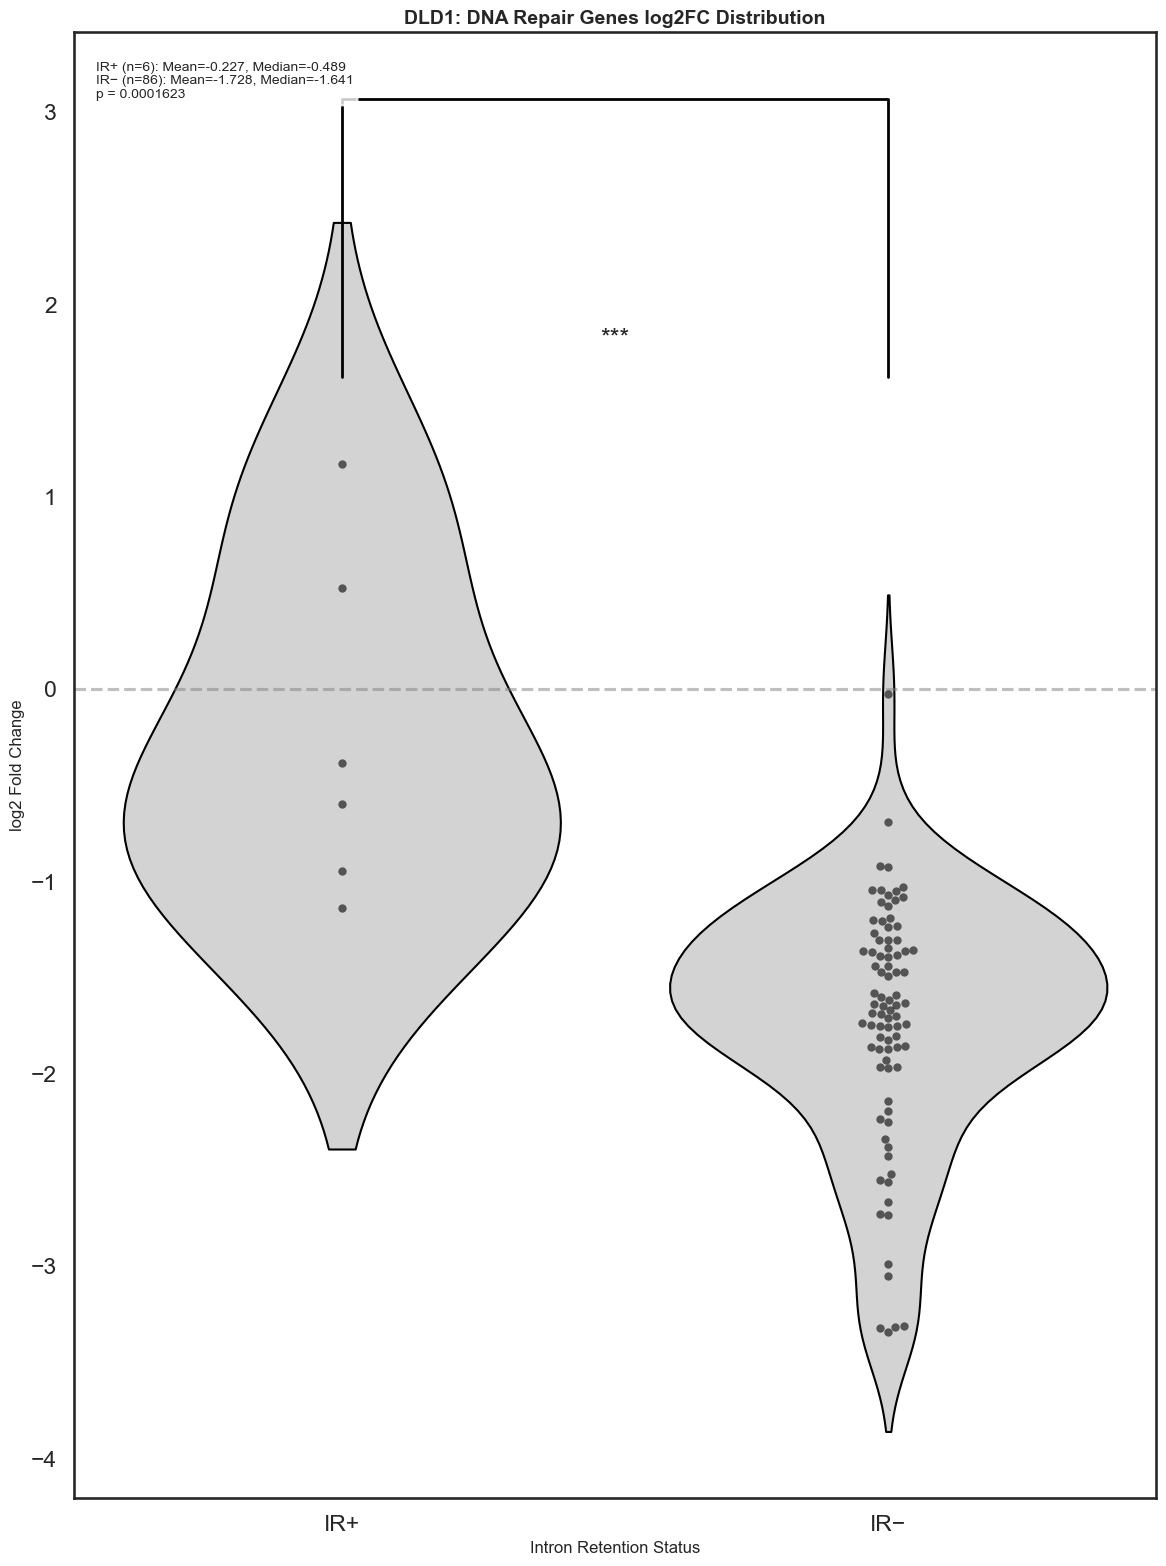


Processing: CAL51
  Total expressed DNA repair genes: 91
  IR+ DNA repair genes: 3 {'FOXM1', 'TAF10', 'SIRT7'}
  IR− DNA repair genes: 88 {'AKTIP', 'INO80', 'NEIL3', 'EXO5', 'USP47', 'MUS81', 'RAD54L', 'CEBPG', 'RHNO1', 'TOP3B', 'CDC7', 'UBE2B', 'EYA4', 'POLH', 'BLM', 'TAF6L', 'TRAIP', 'TP73', 'PIAS4', 'POLL', 'RNF8', 'DTX3L', 'RAD18', 'SMARCAL1', 'USP22', 'EXO1', 'RECQL5', 'ALKBH1', 'BARD1', 'TOP3A', 'REXO4', 'YEATS4', 'SLX4', 'RAD51D', 'GTF2H2C', 'SETD2', 'EYA3', 'BRIP1', 'PARP2', 'TAF4', 'BRCA1', 'ING3', 'NFRKB', 'DCLRE1A', 'SMARCE1', 'XPC', 'RFC3', 'RAD52', 'PMS2', 'TNKS1BP1', 'POLK', 'MBD4', 'INIP', 'ATXN7L3', 'CCDC117', 'PDS5B', 'UPF1', 'BCL7A', 'MBTD1', 'PML', 'BRD8', 'BRCA2', 'TDG', 'TADA1', 'ASF1A', 'NPAS2', 'SMARCAD1', 'DPF1', 'ERCC6', 'USP3', 'TREX1', 'RAD9A', 'CDCA5', 'RFC4', 'PARG', 'ARID2', 'SUPT20H', 'ANKLE1', 'ATRIP', 'DOT1L', 'ARID1A', 'ACTR8', 'POLM', 'FANCM', 'ATXN7', 'USP45', 'DPF2', 'EPC2'}
CAL51
/Users/luqiao/Library/CloudStorage/OneDrive-Stanford/CDK11-paper/IR_

/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_40482/2904385913.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='log2FoldChange', data=combined_df,


<Figure size 640x480 with 0 Axes>

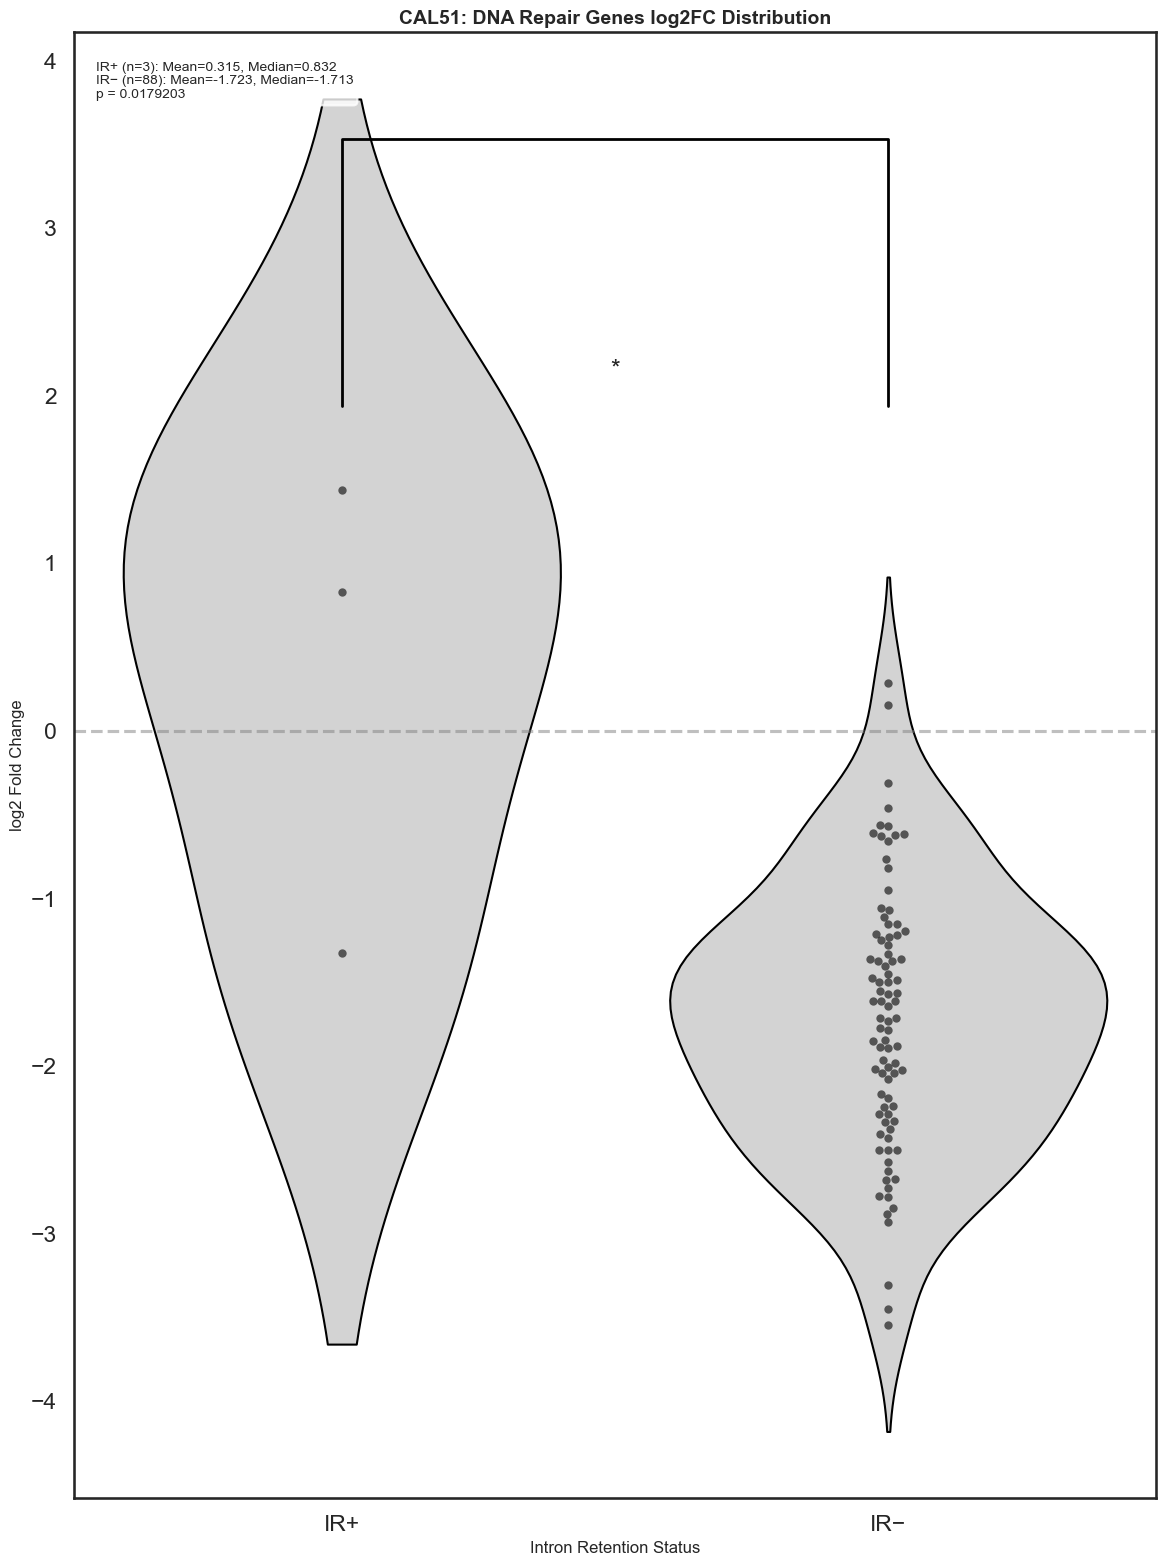


Processing: A375
  Total expressed DNA repair genes: 92
  IR+ DNA repair genes: 7 {'USP22', 'SMARCE1', 'SIRT7', 'NPAS2', 'TAF10', 'FOXM1', 'POLL'}
  IR− DNA repair genes: 85 {'AKTIP', 'INO80', 'NEIL3', 'EXO5', 'USP47', 'MUS81', 'RAD54L', 'CEBPG', 'RHNO1', 'TOP3B', 'CDC7', 'UBE2B', 'EYA4', 'POLH', 'BLM', 'TAF6L', 'TRAIP', 'TP73', 'PIAS4', 'RNF8', 'DTX3L', 'RAD18', 'SMARCAL1', 'EXO1', 'RECQL5', 'ALKBH1', 'BARD1', 'TOP3A', 'REXO4', 'YEATS4', 'SLX4', 'RAD51D', 'GTF2H2C', 'SETD2', 'EYA3', 'BRIP1', 'PARP2', 'TAF4', 'BRCA1', 'ING3', 'NFRKB', 'DCLRE1A', 'XPC', 'RFC3', 'RAD52', 'PMS2', 'TNKS1BP1', 'POLK', 'MBD4', 'INIP', 'ATXN7L3', 'CCDC117', 'PDS5B', 'UPF1', 'BCL7A', 'MBTD1', 'PML', 'BRD8', 'BRCA2', 'TDG', 'TADA1', 'ASF1A', 'SMARCAD1', 'DPF1', 'ERCC6', 'USP3', 'TREX1', 'RAD9A', 'CDCA5', 'RFC4', 'PARG', 'ARID2', 'EYA1', 'SUPT20H', 'ANKLE1', 'ATRIP', 'DOT1L', 'ARID1A', 'ACTR8', 'POLM', 'FANCM', 'ATXN7', 'USP45', 'DPF2', 'EPC2'}
A375
/Users/luqiao/Library/CloudStorage/OneDrive-Stanford/CDK11-pap

/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_40482/2904385913.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='log2FoldChange', data=combined_df,


<Figure size 640x480 with 0 Axes>

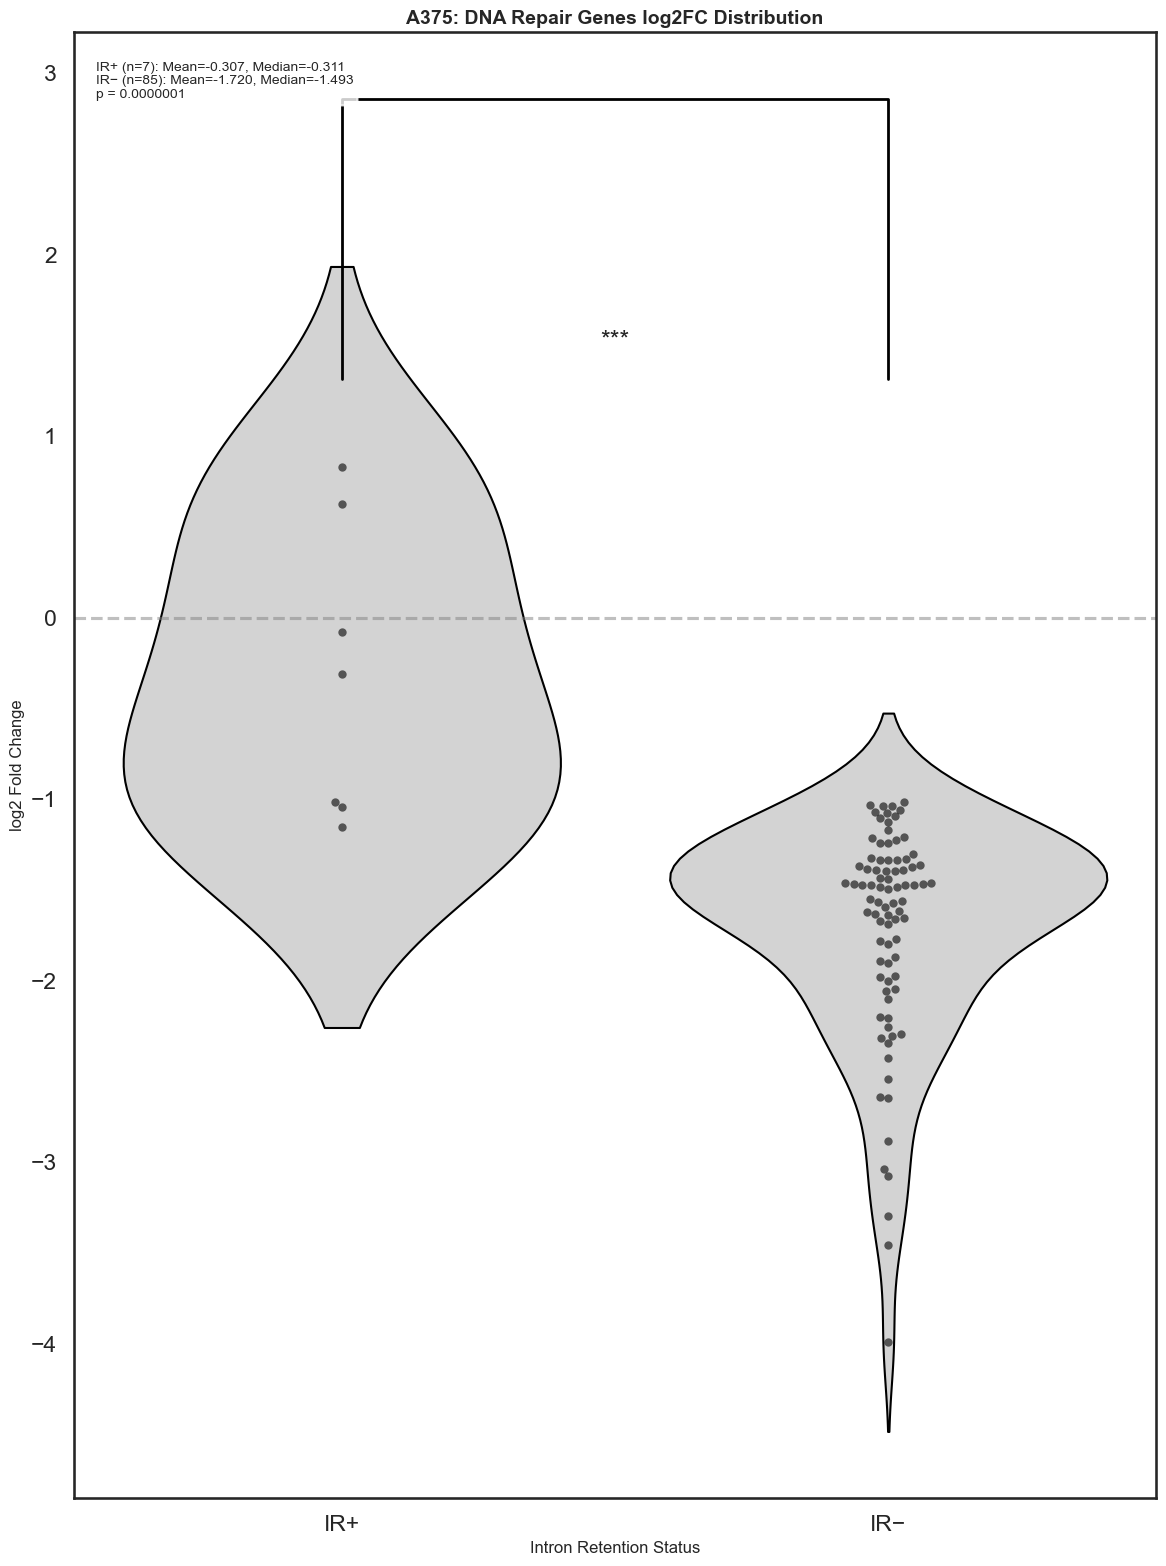


Processing: MDA-MB-231
  Total expressed DNA repair genes: 92
  IR+ DNA repair genes: 1 {'MUS81'}
  IR− DNA repair genes: 91 {'AKTIP', 'INO80', 'NEIL3', 'EXO5', 'TAF10', 'USP47', 'RAD54L', 'CEBPG', 'RHNO1', 'TOP3B', 'CDC7', 'UBE2B', 'EYA4', 'POLH', 'BLM', 'TAF6L', 'TRAIP', 'TP73', 'PIAS4', 'POLL', 'RNF8', 'DTX3L', 'RAD18', 'SMARCAL1', 'USP22', 'SIRT7', 'EXO1', 'RECQL5', 'ALKBH1', 'BARD1', 'TOP3A', 'REXO4', 'YEATS4', 'SLX4', 'RAD51D', 'GTF2H2C', 'SETD2', 'EYA3', 'BRIP1', 'PARP2', 'TAF4', 'BRCA1', 'ING3', 'NFRKB', 'DCLRE1A', 'SMARCE1', 'XPC', 'RFC3', 'RAD52', 'PMS2', 'TNKS1BP1', 'POLK', 'MBD4', 'INIP', 'ATXN7L3', 'CCDC117', 'PDS5B', 'UPF1', 'BCL7A', 'MBTD1', 'PML', 'BRD8', 'BRCA2', 'TDG', 'TADA1', 'ASF1A', 'NPAS2', 'SMARCAD1', 'DPF1', 'ERCC6', 'USP3', 'TREX1', 'RAD9A', 'CDCA5', 'RFC4', 'PARG', 'ARID2', 'EYA1', 'SUPT20H', 'ANKLE1', 'ATRIP', 'DOT1L', 'ARID1A', 'ACTR8', 'POLM', 'FANCM', 'ATXN7', 'USP45', 'FOXM1', 'DPF2', 'EPC2'}
MDA-MB-231
/Users/luqiao/Library/CloudStorage/OneDrive-Stanfo

/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_40482/2904385913.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x='Group', y='log2FoldChange', data=combined_df,


<Figure size 640x480 with 0 Axes>

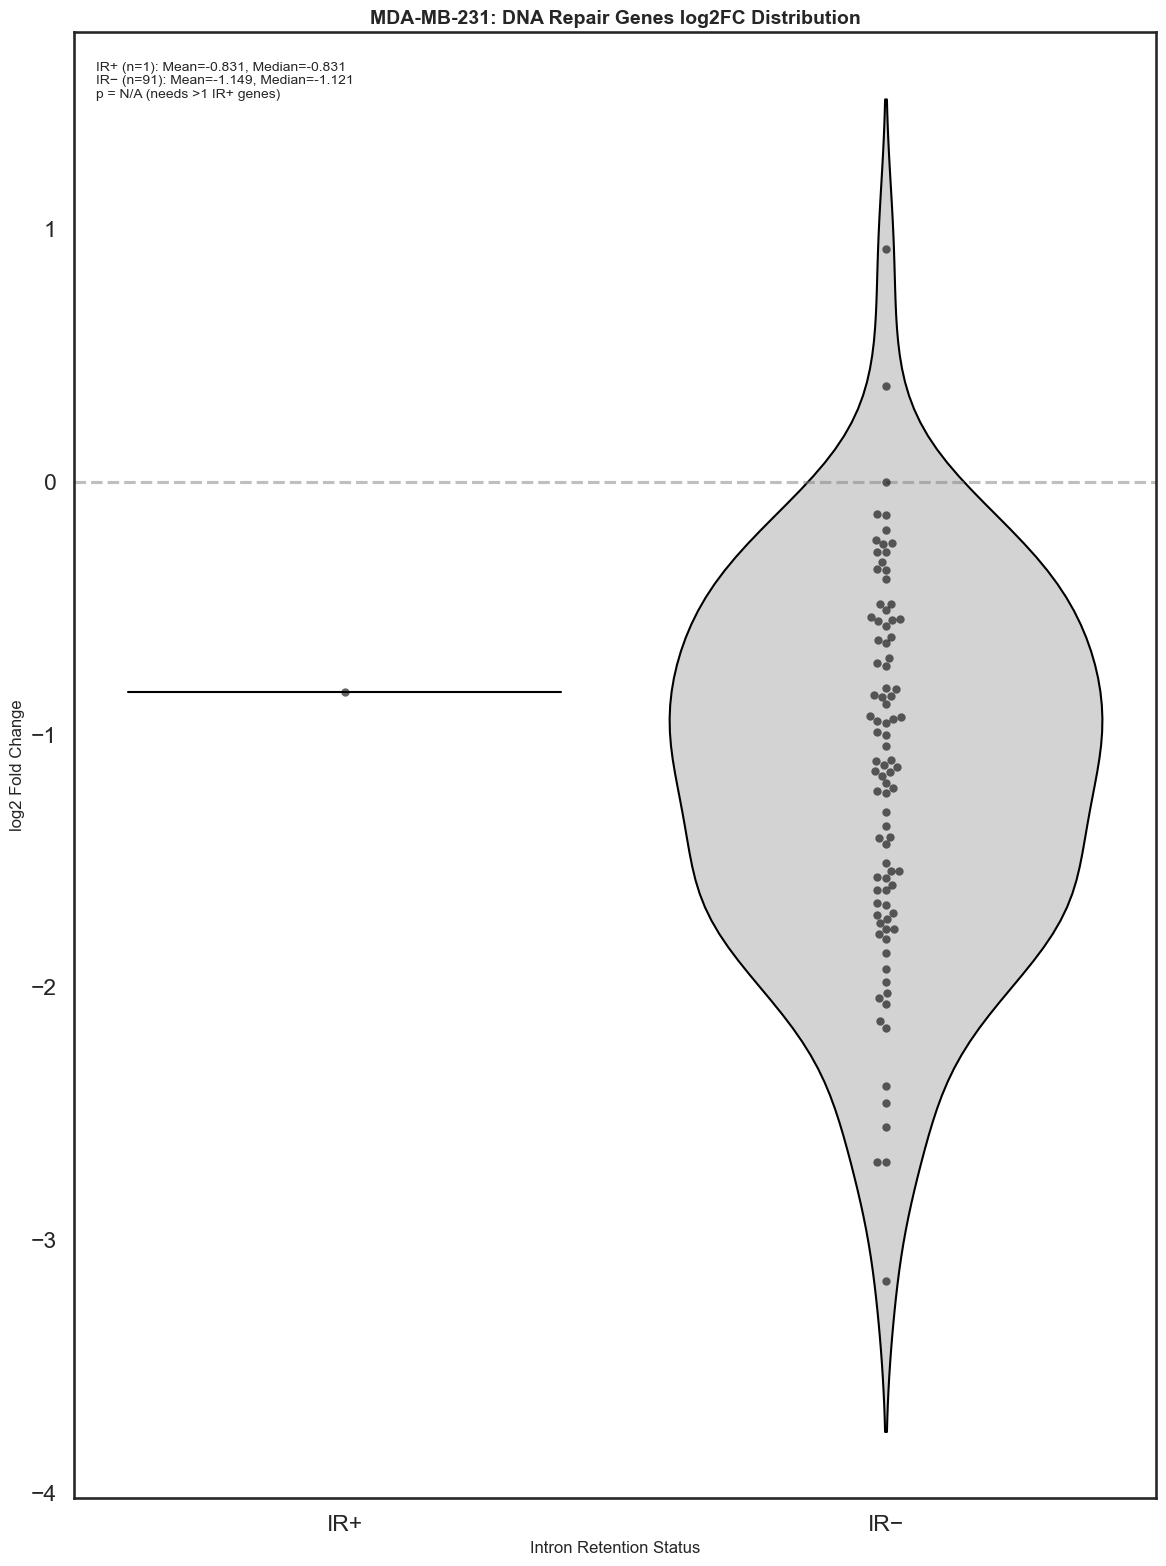


Summary of IR effect on DNA repair gene expression:
    cell_line  n_ir  n_non_ir  mean_lfc_ir  mean_lfc_non_ir    t_pval  \
0        DLD1     6        86    -0.226683        -1.728034  0.008733   
1       CAL51     3        88     0.315000        -1.722794  0.134517   
2        A375     7        85    -0.306714        -1.719547  0.003339   
3  MDA-MB-231     1        91    -0.830900        -1.149249       NaN   

         u_pval  
0  1.622678e-04  
1  1.792031e-02  
2  9.885219e-08  
3  6.956522e-01  


<Figure size 640x480 with 0 Axes>

In [ ]:
# Investigating whether intron retention causes DNA repair gene downregulation - KEEP THIS

from calendar import c
import pandas as pd
import os
from scipy.stats import ttest_ind, mannwhitneyu
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# List of 4 cell lines
cell_lines = ['DLD1', 'CAL51', 'A375', 'MDA-MB-231']

# Directory paths
base_dir = 'paper'
rna_dir = os.path.join(base_dir, 'RNA-seq/Cell_Line_Data_Analysed')
ir_dir = os.path.join(base_dir, 'IR')
plot_output_dir = 'paper'

# No expression threshold - use all expressed genes

# Combined list of DNA repair and repair-related genes
dna_repair_genes = set([
    'MUS81','SMARCAL1','DCLRE1A','SETD2','GTF2H2C','BRCA1','BRCA2','EXO1','ALKBH1','TNKS1BP1','EXO5','POLL','POLK','POLH',
    'TOP3B','PIAS4','UPF1','USP47','RFC3','RFC4','DTX3L','PARP2','USP3','AKTIP','TOP3A','USP45','ACTR8','INIP','REXO4','TRAIP',
    'NEIL3','RAD51D','ASF1A','RHNO1','BLM','CDCA5','DOT1L','RNF8','XPC','PDS5B','BRIP1','RECQL5','SLX4','TDG','PMS2','RAD54L',
    'ATRIP','BARD1','MBD4','FANCM','UBE2B','EYA1','TREX1','EYA3','RAD18','TP73','RAD9A','CDC7','ANKLE1','SMARCAD1','POLM',
    'SMARCE1','TAF10','SIRT7','NPAS2','FOXM1','PARG','CEBPG','RNF8','YEATS4','BRCA1','MBTD1','ING3','BCL7A','ATXN7','DPF1',
    'DPF2','EPC2','SUPT20H','BRD8','ARID2','ATXN7L3','NFRKB','ATRIP','POLH','BARD1','EYA1','EYA3','USP22','EYA4','INO80',
    'ACTR8','CCDC117','SIRT7','ARID1A','PML','RAD52','TAF6L','TADA1','ERCC6','TAF4'
])
#dna_repair_genes = {gene.strip() for gene in gene_list_raw.replace("\n", "").split(";") if gene.strip()}

results = []

def create_violin_plot(df_ir, df_non_ir, cell_line, output_dir=None):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    ir_data = pd.DataFrame({'log2FoldChange': df_ir['log2FoldChange'], 'Group': 'IR+'})
    non_ir_data = pd.DataFrame({'log2FoldChange': df_non_ir['log2FoldChange'], 'Group': 'IR−'})
    combined_df = pd.concat([ir_data, non_ir_data])

    ir_mean = df_ir['log2FoldChange'].mean()
    ir_median = df_ir['log2FoldChange'].median()
    non_ir_mean = df_non_ir['log2FoldChange'].mean()
    non_ir_median = df_non_ir['log2FoldChange'].median()

    # Mann-Whitney U test
    if len(df_ir) > 1:
        try:
            _, p_value = mannwhitneyu(df_ir['log2FoldChange'], df_non_ir['log2FoldChange'])
            p_text = f"p = {p_value:.7f}"
        except:
            p_value = None
            p_text = "p = N/A"
    else:
        p_value = None
        p_text = "p = N/A (needs >1 IR+ genes)"

    # Plotting
    plt.figure(figsize=(12, 16))
    ax = sns.violinplot(x='Group', y='log2FoldChange', data=combined_df,
                        inner=None, palette={'IR+': 'lightgray', 'IR−': 'lightgray'},
                        linewidth=1.5, edgecolor='black')
    sns.swarmplot(x='Group', y='log2FoldChange', data=combined_df,
                  color='black', alpha=0.6, size=6)
    plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.grid(False)

    plt.title(f'{cell_line}: DNA Repair Genes log2FC Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Intron Retention Status', fontsize=12)
    plt.ylabel('log2 Fold Change', fontsize=12)

    # Text box with summary stats
    stats_text = (f"IR+ (n={len(df_ir)}): Mean={ir_mean:.3f}, Median={ir_median:.3f}\n"
                  f"IR− (n={len(df_non_ir)}): Mean={non_ir_mean:.3f}, Median={non_ir_median:.3f}\n"
                  f"{p_text}")
    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes,
             verticalalignment='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add significance annotation
    if p_value is not None:
        def get_stars(p):
            if p < 0.001:
                return '***'
            elif p < 0.01:
                return '**'
            elif p < 0.05:
                return '*'
            else:
                return 'ns'

        star_text = get_stars(p_value)
        y_max = combined_df['log2FoldChange'].max()
        y_min = combined_df['log2FoldChange'].min()
        h = (y_max - y_min) * 0.1
        ax.plot([0, 0, 1, 1], [y_max + h, y_max + h*4.2, y_max + h*4.2, y_max + h], lw=2, color='black')
        ax.text(0.5, y_max + h*1.3, star_text, ha='center', va='bottom', fontsize=18)

    plt.tight_layout()

    if output_dir:
        plt.savefig(f"{output_dir}/{cell_line}_violin_plots_QL.svg", dpi=300, bbox_inches='tight')
    
    plt.show()
    return plt.gcf()


for cell_line in cell_lines:
    print(f"\nProcessing: {cell_line}")
    
    deseq_path = os.path.join(rna_dir, cell_line, 'WT', 'condition_control_treated_study.deseq2.results.tsv')
    if not os.path.exists(deseq_path):
        print(f"  DESeq2 file missing for {cell_line}, skipping.")
        continue
    de_df = pd.read_csv(deseq_path, sep='\t')
    de_df = de_df[['gene_id', 'log2FoldChange']].dropna()

    all_expressed_genes = set(de_df['gene_id'])

    ir_path = os.path.join(ir_dir, cell_line, '100nm6hr_r10_ir3.sorted.txt')
    if not os.path.exists(ir_path):
        print(f"  IR file missing for {cell_line}, skipping.")
        continue
    ir_df = pd.read_csv(ir_path, sep='\t')
    
    # Get expressed DNA repair genes (all genes found in RNA-seq data)
    expressed_dna_repair_genes = dna_repair_genes & all_expressed_genes
    
    # Classify IR+ genes: DNA repair genes that are in IR file AND pass IR thresholds
    ir_df_filtered = ir_df[(ir_df['ΔPSI (%)'] > 20) & (ir_df['T-test p-value'] < 0.05)].copy()
    ir_genes_passing_thresholds = set(ir_df_filtered['Gene Symbol'].dropna().unique())
    dna_repair_ir = expressed_dna_repair_genes & ir_genes_passing_thresholds
    
    # Classify IR- genes: All other expressed DNA repair genes
    # This includes:
    # 1. Genes not found in IR file at all
    # 2. Genes found in IR file but don't pass thresholds
    dna_repair_non_ir = expressed_dna_repair_genes - dna_repair_ir

    print(f"  Total expressed DNA repair genes: {len(expressed_dna_repair_genes)}")
    print(f"  IR+ DNA repair genes: {len(dna_repair_ir)}", dna_repair_ir)
    print(f"  IR− DNA repair genes: {len(dna_repair_non_ir)}", dna_repair_non_ir)
    
    # Verify the classification is complete and non-overlapping
    assert len(dna_repair_ir) + len(dna_repair_non_ir) == len(expressed_dna_repair_genes), "Classification error: genes don't add up"
    assert len(dna_repair_ir & dna_repair_non_ir) == 0, "Classification error: overlapping genes"

    if len(dna_repair_ir) == 0 or len(dna_repair_non_ir) == 0:
        print(f"  Skipping {cell_line}: one of the groups is empty.")
        continue

    de_df_ir = de_df[de_df['gene_id'].isin(dna_repair_ir)]
    de_df_non_ir = de_df[de_df['gene_id'].isin(dna_repair_non_ir)]

    violin_df_ir = de_df_ir.copy()
    violin_df_ir['IR_status'] = 'IR+'
    violin_df_ir = violin_df_ir.rename(columns={'gene_id': 'gene'})

    violin_df_non_ir = de_df_non_ir.copy()
    violin_df_non_ir['IR_status'] = 'IR-'
    violin_df_non_ir = violin_df_non_ir.rename(columns={'gene_id': 'gene'})

    violin_df_combined = pd.concat([violin_df_ir, violin_df_non_ir])
    print(cell_line)
    violin_csv_path = os.path.join(plot_output_dir, f'{cell_line}_violin_data_QL.csv')
    violin_df_combined[['gene', 'log2FoldChange', 'IR_status']].to_csv(violin_csv_path, index=False)
    print(violin_csv_path)
    print(violin_df_combined)

    results.append({
        'cell_line': cell_line,
        'n_ir': len(de_df_ir),
        'n_non_ir': len(de_df_non_ir),
        'mean_lfc_ir': de_df_ir['log2FoldChange'].mean(),
        'mean_lfc_non_ir': de_df_non_ir['log2FoldChange'].mean(),
        't_pval': ttest_ind(de_df_ir['log2FoldChange'], de_df_non_ir['log2FoldChange'], equal_var=False).pvalue,
        'u_pval': mannwhitneyu(de_df_ir['log2FoldChange'], de_df_non_ir['log2FoldChange'], alternative='two-sided').pvalue
    })

    # Create output directory for plots
    plot_output_dir = os.path.join(base_dir, 'IR_in_DNA_Repair')
    os.makedirs(plot_output_dir, exist_ok=True)
    
    create_violin_plot(de_df_ir, de_df_non_ir, cell_line, plot_output_dir)

summary_df = pd.DataFrame(results)
print("\nSummary of IR effect on DNA repair gene expression:")
print(summary_df)

# S6B

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# Step 1: Load the OmicsSomaticMutationsMatrixDamaging.csv file from depmap
omics_data = pd.read_csv('OmicsSomaticMutationsMatrixDamaging.csv', index_col=0)
omics_data.columns = omics_data.columns.str.extract(r'([^\s]+)')[0]  # Extract gene names from column headers

# Step 2: Filter genes mutated in >5% of cell lines
# Considering genes with values 1 or 2 as mutated
mutation_frequency = ((omics_data == 1) | (omics_data == 2)).sum() / omics_data.shape[0]  # Calculate mutation frequency
filtered_genes = mutation_frequency[mutation_frequency > 0.02].index  # Genes mutated in >1% of cell lines
omics_data_filtered = omics_data[filtered_genes]

# Step 3: Load the CDK11B dependency score data
cdk11b_dependency = pd.read_csv('CDK11B_CRISPR_Project_Score_CERES.csv')
cdk11b_dependency = cdk11b_dependency[['Depmap ID', 'CRISPR (Project Score, CERES)']]
cdk11b_dependency.set_index('Depmap ID', inplace=True)

# Step 4: Align the datasets using common cell lines
common_cell_lines = omics_data_filtered.index.intersection(cdk11b_dependency.index)
omics_data_aligned = omics_data_filtered.loc[common_cell_lines]
cdk11b_dependency_aligned = cdk11b_dependency.loc[common_cell_lines]

# Step 5: Correlate the CDK11B dependency scores with each column in the Omics data
correlation_results = omics_data_aligned.apply(
    lambda x: np.corrcoef(cdk11b_dependency_aligned['CRISPR (Project Score, CERES)'], x)[0, 1]
)

# Step 6: Sort the correlation results and prepare for plotting
correlation_sorted = correlation_results.sort_values(ascending=True)

# Apply Gaussian smoothing to the correlation results
smoothed_correlation = gaussian_filter1d(correlation_sorted.values, sigma=1)

# Step 7: Read in genes to highlight from genes.txt and remove duplicates
highlight_genes = pd.read_csv('Figure4/Genes.txt', header=None)[0].tolist()
highlight_genes = list(set(highlight_genes))  # Remove duplicates

# Step 8: Create a scatter plot with specified genes highlighted
plt.figure(figsize=(40, 32), dpi=300)

# Determine colors, highlighting any genes found in the genes.txt file
colors = ['red' if gene in highlight_genes else 'black' for gene in correlation_sorted.index]

plt.scatter(range(len(correlation_sorted))[::-1], correlation_sorted, color=colors, s=800)

# Add continuous smooth line connecting the points
#plt.plot(range(len(smoothed_correlation))[::-1], smoothed_correlation, color='gray', linewidth=20)

# Customize plot spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(10)
ax.spines['bottom'].set_linewidth(10)

plt.ylim(-0.2,0.4)

# Add labels and title
plt.ylabel('CDK11B Dependency - \nMutation Count Correlation', fontsize=130, fontweight='bold')
plt.xlabel('Gene Rank', fontsize=120, labelpad=60, fontweight='bold')
plt.title('Genome-wide Mutation Count Analysis', fontsize=120, pad=160, fontweight='bold')

#plt.xticks(fontsize=120)
plt.yticks(fontsize=120)

# Add arrows and labels for CDK11A, CDK11B, and CCNL2
genes = ['CDK11A','CCNL2', 'CDK11B']
y_offsets = [-0.1, 0, 0]

for gene, offset in zip(genes, y_offsets):
    if gene in correlation_sorted.index:
        x = len(correlation_sorted) - correlation_sorted.index.get_loc(gene) - 1
        y = correlation_sorted[gene]

        plt.annotate(gene,
                     xy=(x, y), 
                     xytext=(x + 4000, y + offset),
                     arrowprops=dict(facecolor='blue', arrowstyle="->", lw=6),
                     fontsize=120, color='blue', ha='right')
    else:
        print(f'{gene} did not pass mutation filter')

# Add a legend with custom labels for the groups
plt.scatter([], [], color='red', label='Located on \nChr1p.36', s=1200)
plt.scatter([], [], color='black', label='Not located on \nChr1p.36', s=1200)
plt.legend(fontsize=100, frameon=False, loc='upper right')

# Save the plot
# plt.savefig('Waterfall_Mutation_Count_Filtered.png', bbox_inches='tight', dpi=300, pad_inches=0.5)
plt.show()

# S7A

0.011462763703193527


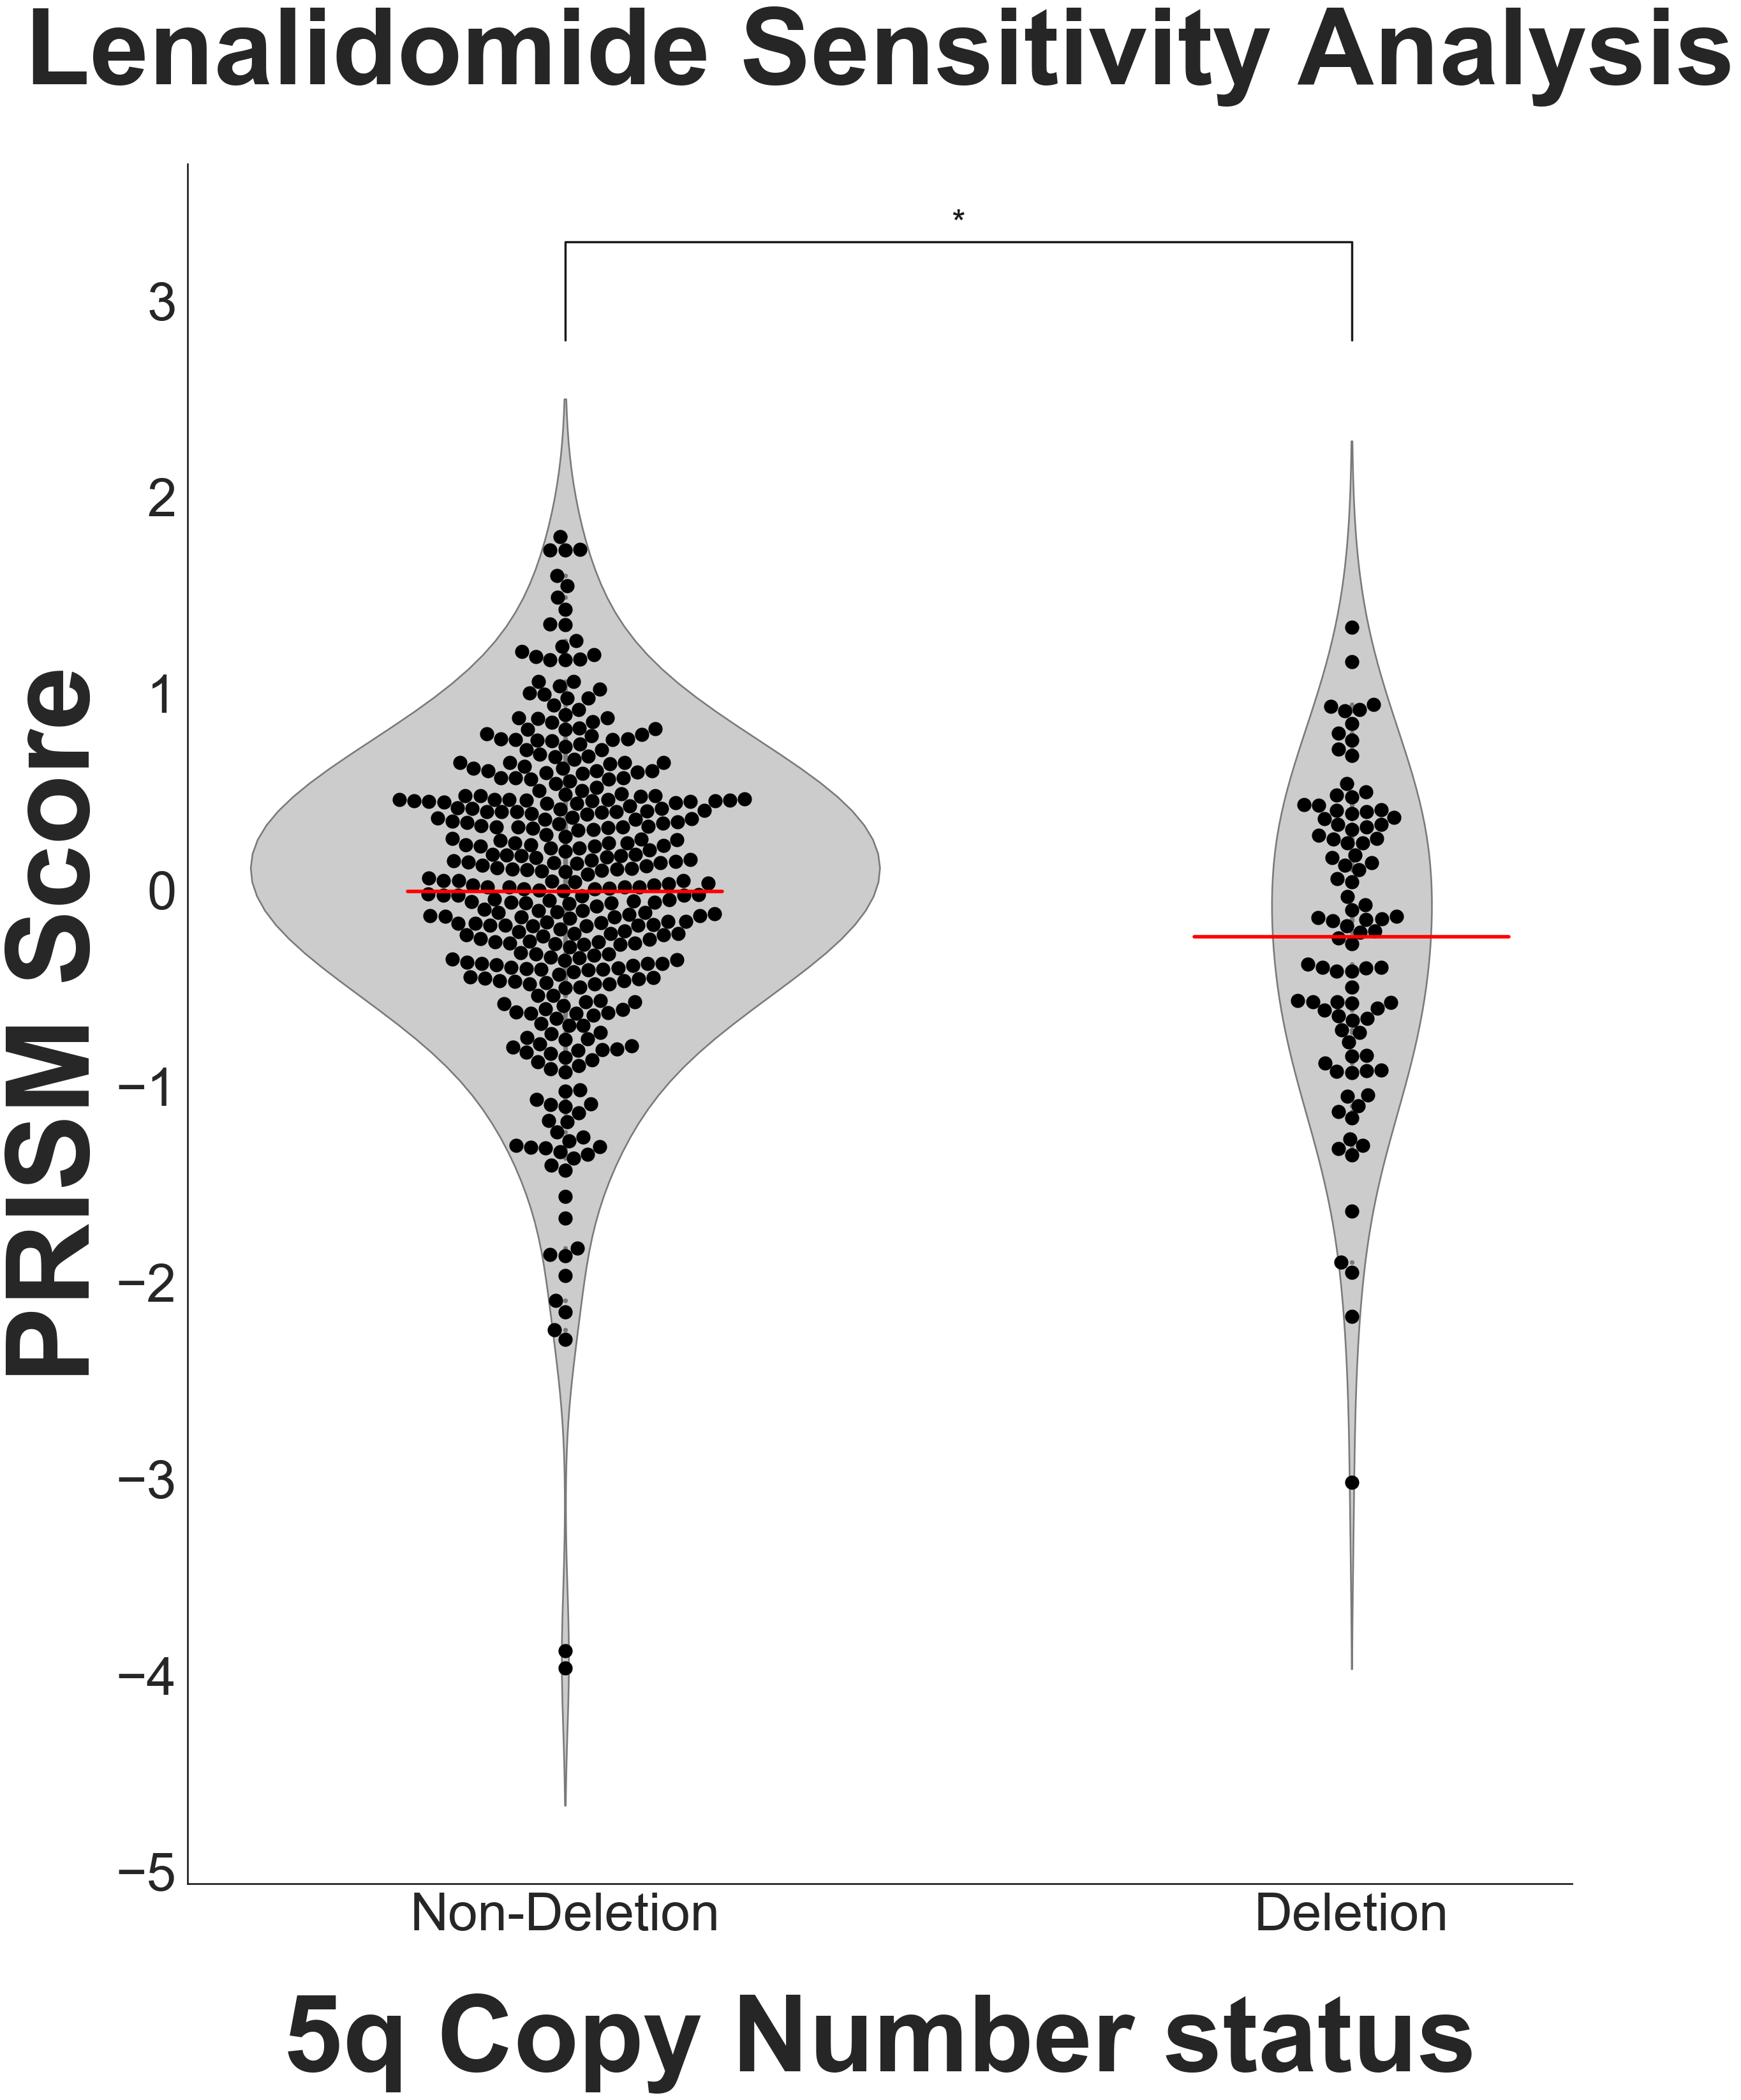

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# -------------------------------
# 1. Load the CSV files
# -------------------------------
# Lenalidomide file containing log2 expression values
all_prism_data_file = r'Supplementary_Figs/data/Drug_sensitivity_dose-level_PRISM_Repurposing_Secondary_Screen.csv'
df_lenalidomide = pd.read_csv(all_prism_data_file)
df_lenalidomide = df_lenalidomide[['Depmap ID', 'LENALIDOMIDE (BRD:BRD-A17883755-001-06-1) 2.5μM']]

# Arm-level CNA file with the "5q" column
cna_file = r'Supplementary_Figs/data/Arm-level_CNAs_subsetted.csv'
df_cna = pd.read_csv(cna_file)

# -------------------------------
# 2. Merge the DataFrames on 'Depmap ID'
# -------------------------------
merged_df = pd.merge(df_lenalidomide, df_cna, on='Depmap ID', how='inner')

# -------------------------------
# 3. Categorize cell lines into "Deletion" and "Non-Deletion"
# -------------------------------
def categorize_cna(cna_val):
    """
    Categorizes copy number values:
      - Deletion: CNA < 0
      - Non-Deletion: CNA >= 0 (combining Gain and Neutral)
    """
    return 'Deletion' if cna_val < 0.0 else 'Non-Deletion'

# Apply categorization
merged_df['cn_category'] = merged_df['5q'].apply(categorize_cna)

# Define the new order for categories
category_order = ['Non-Deletion', 'Deletion']

# -------------------------------
# 4. Create a violin plot with swarm overlay
# -------------------------------

# The y-axis will be the log2 expression values from the "PRISM" dataset
y_column = 'LENALIDOMIDE (BRD:BRD-A17883755-001-06-1) 2.5μM'

# Set the plotting style
sns.set(style="white", context="talk")

plt.figure(figsize=(28, 35))
ax = sns.violinplot(x='cn_category', y=y_column, data=merged_df,
                    order=category_order, color=".8", density_norm="count", inner='point', bw_adjust=1.5)

# Overlay the individual data points with a swarm plot
sns.swarmplot(x='cn_category', y=y_column, data=merged_df,
              order=category_order, color='black', size=16, zorder=10, ax=ax)

# Turn off grid lines
ax.grid(False)

# Calculate and plot the group means
group_means = merged_df.groupby('cn_category')[y_column].mean().reindex(category_order)
for i, mean in enumerate(group_means):
    ax.plot([i - 0.2, i + 0.2], [mean, mean],
            color='red', linestyle='-', linewidth=4, zorder=10)

# Customize x-axis ticks and spines
plt.xticks(ticks=[0, 1], labels=category_order, fontsize=14)
ax.tick_params(axis='x', length=0, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# -------------------------------
# 5. Perform t-test between "Deletion" and "Non-Deletion"
# -------------------------------

# Extract values for comparison
deletion_vals = merged_df[merged_df['cn_category'] == 'Deletion'][y_column].dropna()
non_deletion_vals = merged_df[merged_df['cn_category'] == 'Non-Deletion'][y_column].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(deletion_vals, non_deletion_vals, alternative='two-sided', equal_var=False)
print(p_value)
# Define helper function to add statistical annotation
def add_stat_annotation(ax, p_value, x1, x2, y, h, color='k'):
    """Draws a line with significance stars between two groups."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, color=color)
    
    # Determine significance star based on p-value
    if p_value < 0.001:
        star_label = '***'
    elif p_value < 0.01:
        star_label = '**'
    elif p_value < 0.05:
        star_label = '*'
    else:
        star_label = 'ns'
    
    ax.text((x1 + x2) * 0.5, y + h, star_label,
            ha='center', va='bottom', color=color, fontsize=40)

# Set a y-position for annotations above the max observed value
y_max = merged_df[y_column].max()

# Annotate the comparison: Non-Deletion vs Deletion (x positions 0 and 1)
add_stat_annotation(ax, p_value, x1=0, x2=1, y=y_max + 1, h=0.5)

# -------------------------------
# 6. Add plot title and labels, then save and show the plot
# -------------------------------
plt.title('Lenalidomide Sensitivity Analysis', fontsize=120, pad=90, fontweight='bold')
plt.xlabel('5q Copy Number status', fontsize=120, labelpad=60, fontweight='bold')
plt.ylabel('PRISM Score', fontsize=130, fontweight='bold')
plt.xticks(fontsize=60)
plt.yticks(fontsize=60)

# Save the figure
# plt.savefig(r'Supplementary_Figs/Lenalidomide_5q_Deletion_vs_NonDeletion_QL.png', bbox_inches='tight')

plt.show()


# S7D

nan


/opt/anaconda3/envs/everyday/lib/python3.13/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


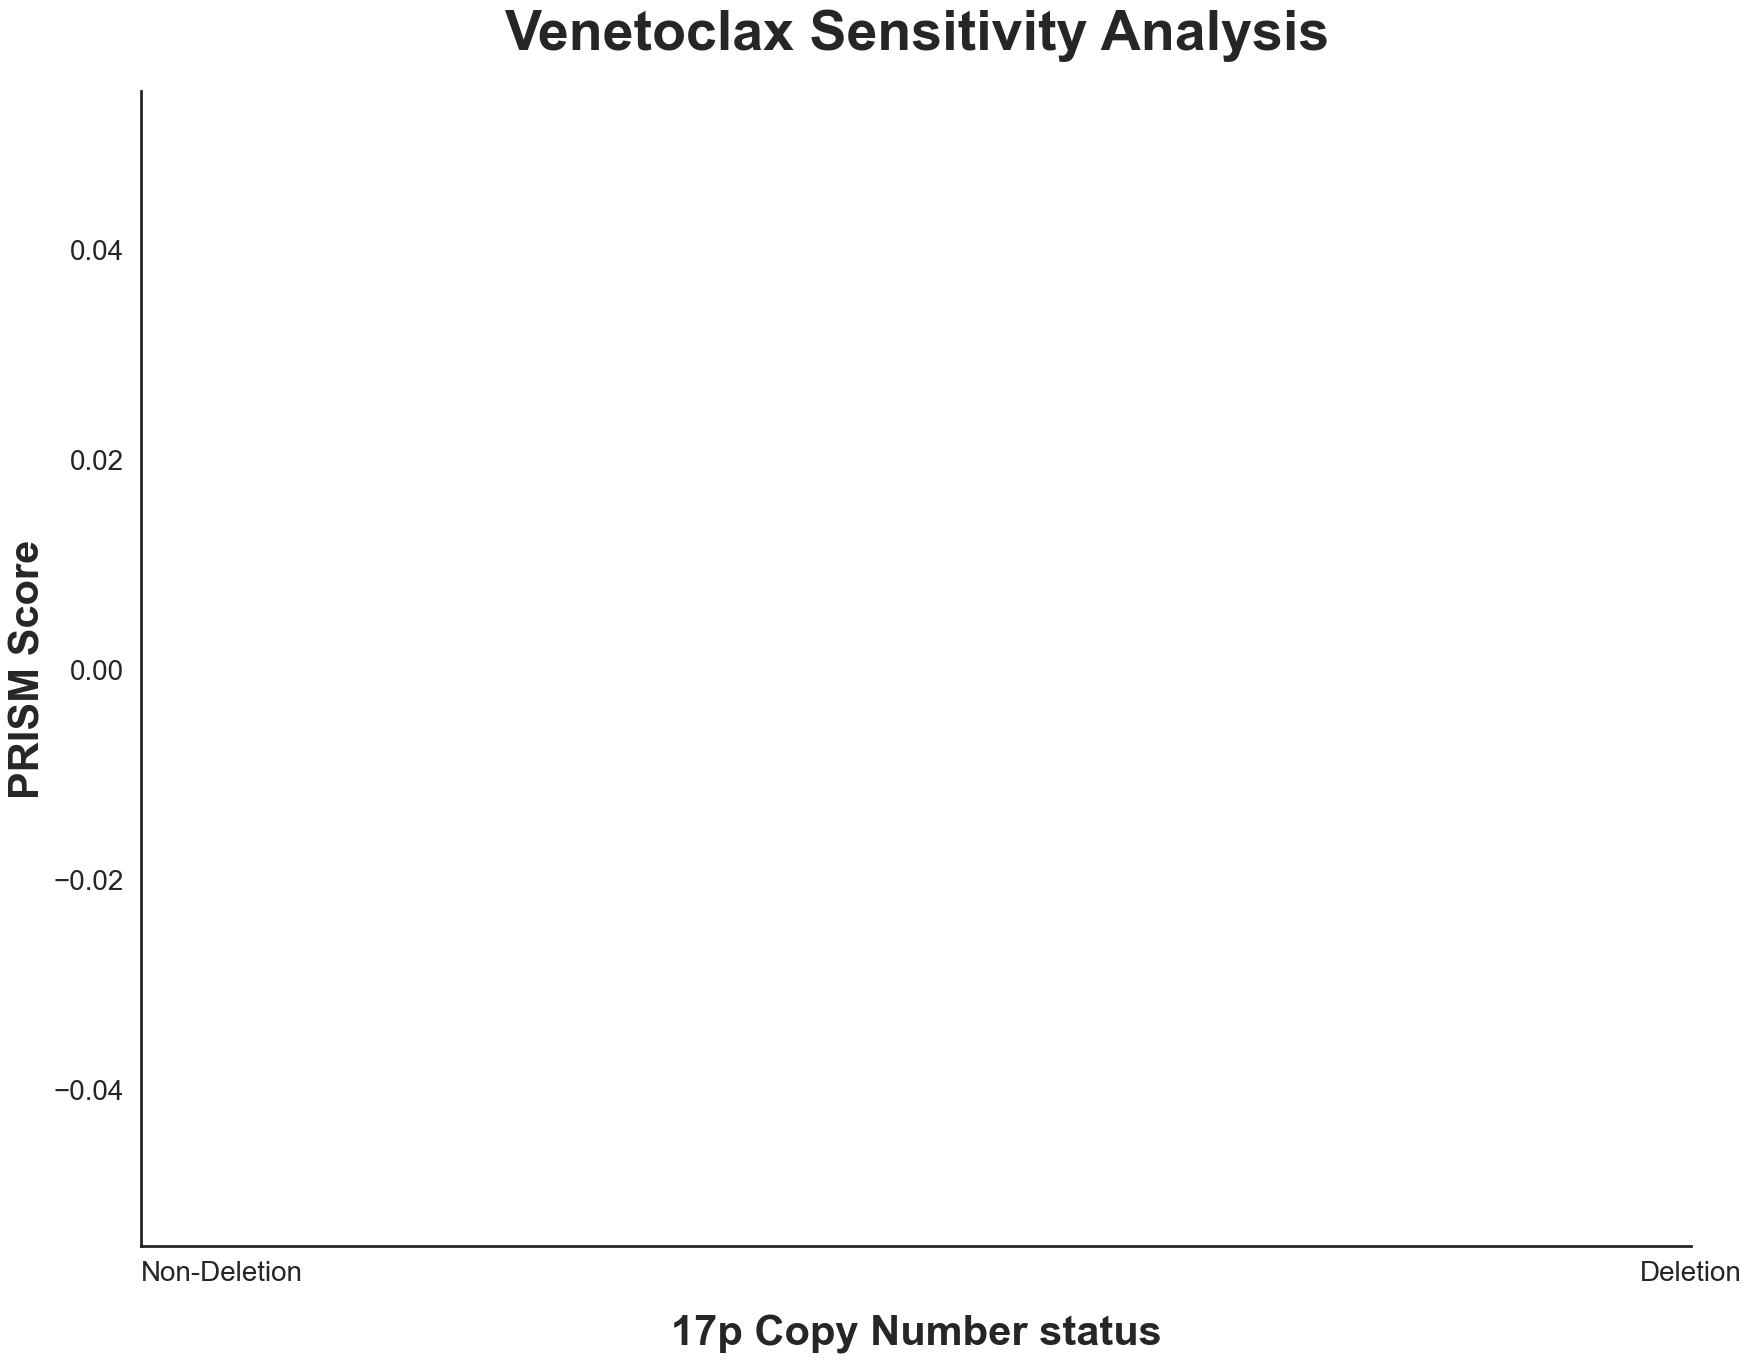

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# -------------------------------
# 1. Load the CSV files
# -------------------------------
# Venetoclax file containing log2 expression values
all_prism_data_file = r'Drug_sensitivity_dose-level_(PRISM_Repurposing_Secondary_Screen)_subsetted.csv'
all_prism_data_file = r'Supplementary_Figs/Venetoclax_Plot_Data.csv'
df_lenalidomide = pd.read_csv(all_prism_data_file)

# Ensure the first column is named 'Depmap ID'
if df_lenalidomide.columns[0] != "Depmap ID":
    df_lenalidomide.rename(columns={df_lenalidomide.columns[0]: "Depmap ID"}, inplace=True)

# Set 'Depmap ID' as the index
df_lenalidomide.set_index("Depmap ID", inplace=True)

# Select only the required column (without 'Depmap ID')
y_column = 'VENETOCLAX (BRD:BRD-K62391742-001-09-7) 0.0391μM'
df_lenalidomide = df_lenalidomide[[y_column]]

# Arm-level CNA file with the "17p" column
cna_file = r'Supplementary_Figs/data/Arm-level_CNAs_subsetted.csv'
df_cna = pd.read_csv(cna_file)

# -------------------------------
# 2. Merge the DataFrames on 'Depmap ID'
# -------------------------------
merged_df = pd.merge(df_lenalidomide, df_cna, on='Depmap ID', how='inner')

# -------------------------------
# 3. Categorize cell lines based on 17p copy number
# -------------------------------
def categorize_cna(cna_val):
    """
    Categorizes copy number values:
      - Deletion: CNA < 0
      - Non-Deletion: CNA ≥ 0 (combining Neutral and Gain)
    """
    return 'Deletion' if cna_val < 0.0 else 'Non-Deletion'

# Apply categorization based on "17p"
merged_df['cn_category'] = merged_df['17p'].apply(categorize_cna)

# Drop NaN values to ensure valid statistical comparisons
merged_df = merged_df.dropna(subset=[y_column, 'cn_category'])

# Define the order for the categories on the plot
category_order = ['Non-Deletion', 'Deletion']

# -------------------------------
# 4. Create a violin plot with swarm overlay
# -------------------------------

# Set the plotting style
sns.set(style="white", context="talk")

plt.figure(figsize=(20, 15))
ax = sns.violinplot(x='cn_category', y=y_column, data=merged_df,
                    order=category_order, color=".8", density_norm="count", inner='point', bw_adjust=1.5)

# Overlay the individual data points with a swarm plot
sns.swarmplot(x='cn_category', y=y_column, data=merged_df,
              order=category_order, color='black', size=10, zorder=10, ax=ax)

# Turn off grid lines
ax.grid(False)

# Calculate and plot the group means
group_means = merged_df.groupby('cn_category')[y_column].mean().reindex(category_order)
for i, mean in enumerate(group_means):
    ax.plot([i - 0.2, i + 0.2], [mean, mean],
            color='red', linestyle='-', linewidth=4, zorder=10)

# Customize x-axis ticks and spines
plt.xticks(ticks=[0, 1], labels=category_order, fontsize=14)
ax.tick_params(axis='x', length=0, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

# -------------------------------
# 5. Perform Welch's t-test between Deletion and Non-Deletion
# -------------------------------

# Extract log2 expression values by copy-number category
deletion_vals = merged_df[merged_df['cn_category'] == 'Deletion'][y_column].dropna()
non_deletion_vals = merged_df[merged_df['cn_category'] == 'Non-Deletion'][y_column].dropna()

# Perform Welch's t-test (equal_var=False accounts for unequal variances)
t_stat, p_value = ttest_ind(deletion_vals, non_deletion_vals, alternative='two-sided', equal_var=False)
print(p_value)

# Define helper function to add statistical annotation
def add_stat_annotation(ax, p_value, x1, x2, y, h, color='k'):
    """Draws a line with significance stars between two groups."""
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2.5, color=color)
    
    # Determine significance star based on p-value
    if p_value < 0.001:
        star_label = '***'
    elif p_value < 0.01:
        star_label = '**'
    elif p_value < 0.05:
        star_label = '*'
    else:
        star_label = 'ns'
    
    ax.text((x1 + x2) * 0.5, y + h, star_label,
            ha='center', va='bottom', color=color, fontsize=20)

# Set a y-position for annotations above the max observed value
y_max = merged_df[y_column].max()

# Annotate the comparison between Deletion and Non-Deletion
add_stat_annotation(ax, p_value, x1=0, x2=1, y=y_max + 1, h=0.5)

# -------------------------------
# 6. Add plot title and labels, then save and show the plot
# -------------------------------
plt.title('Venetoclax Sensitivity Analysis', fontsize=40, pad=30, fontweight='bold')
plt.xlabel('17p Copy Number status', fontsize=30, labelpad=20, fontweight='bold')
plt.ylabel('PRISM Score', fontsize=30, fontweight='bold')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

# Save the figure (update the path/filename as needed)
# plt.savefig(r'Supplementary_Figs/VClax_CN_log2_expression_Deletion_vs_NonDeletion_QL.png', bbox_inches='tight')

plt.show()


# S8A

CDK11A_expr
6.31170569205266e-49 1.969255452811436e-13


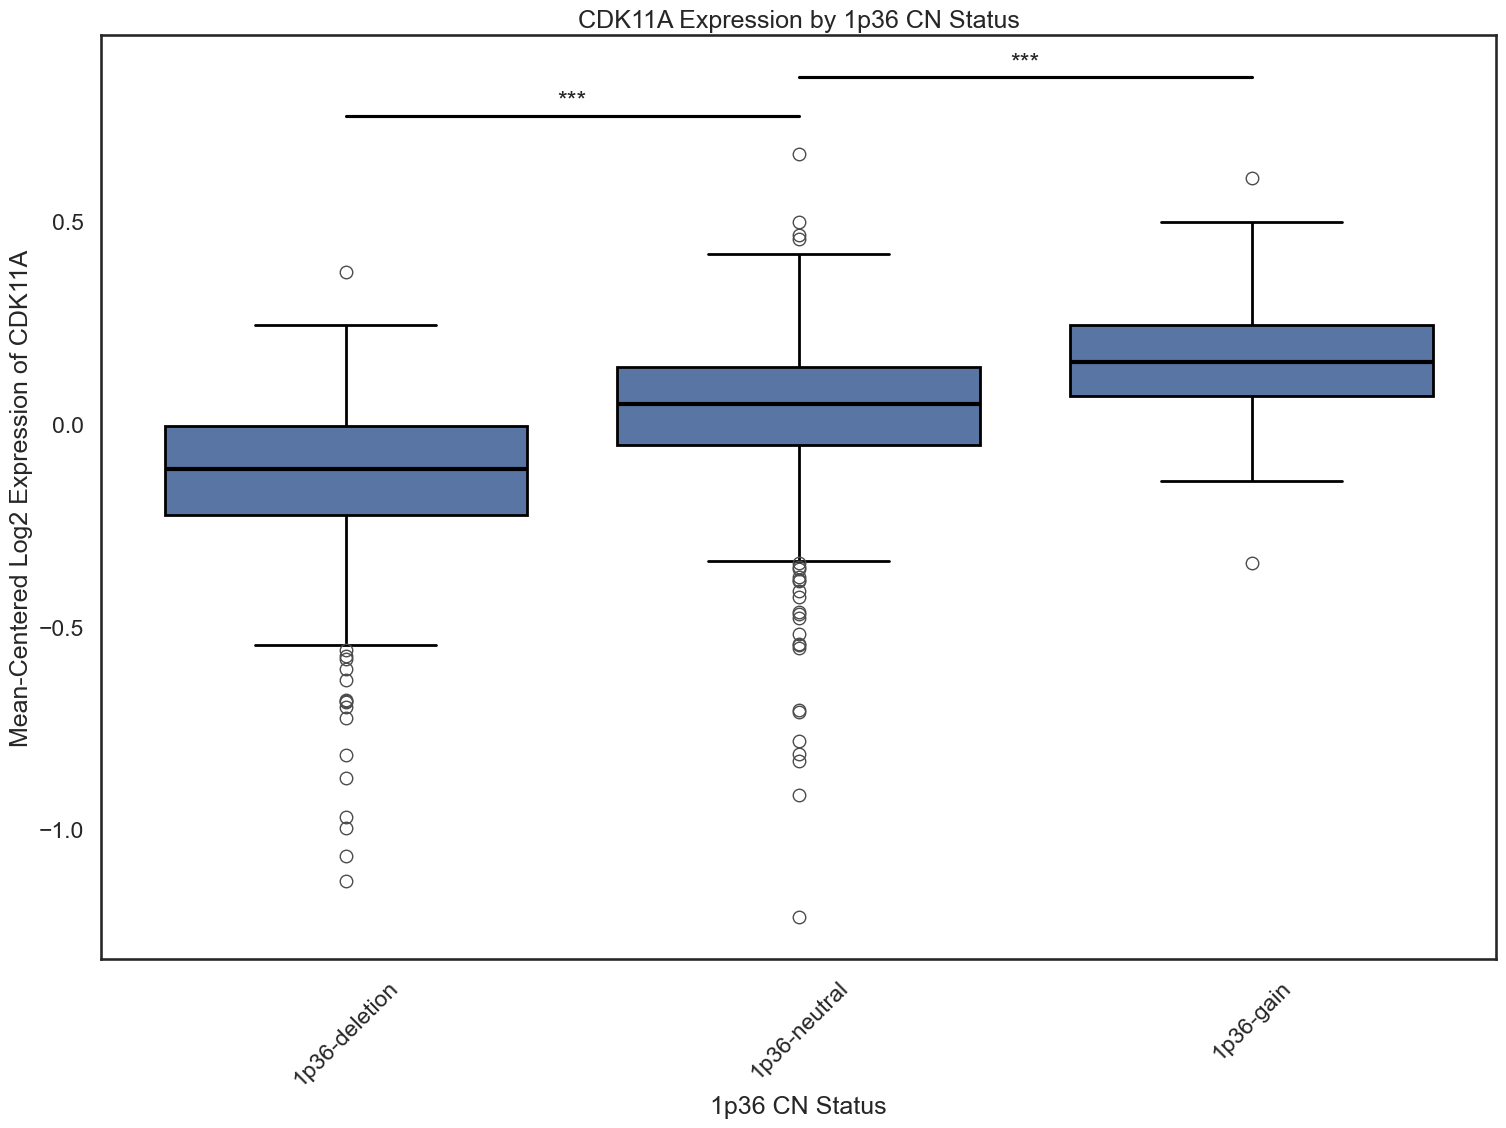

CDK11B_expr
2.007623192354363e-57 9.953231709124423e-22


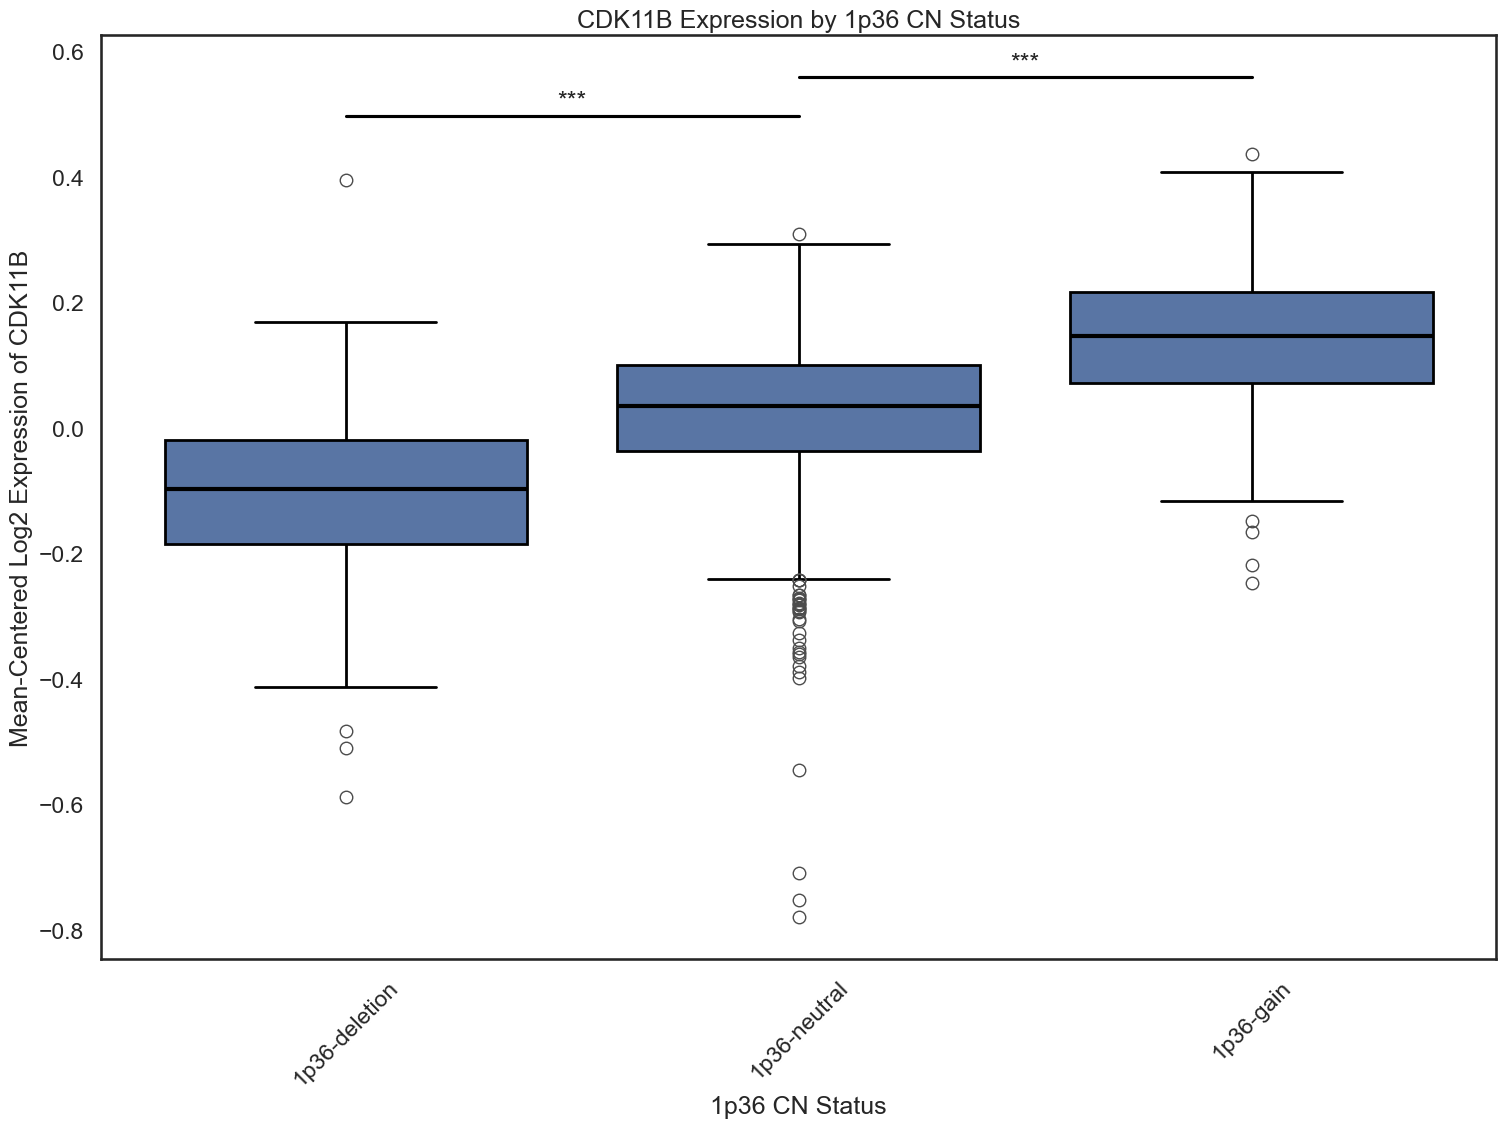

CCNL2_expr
1.6989943166219774e-26 6.704404172956831e-16


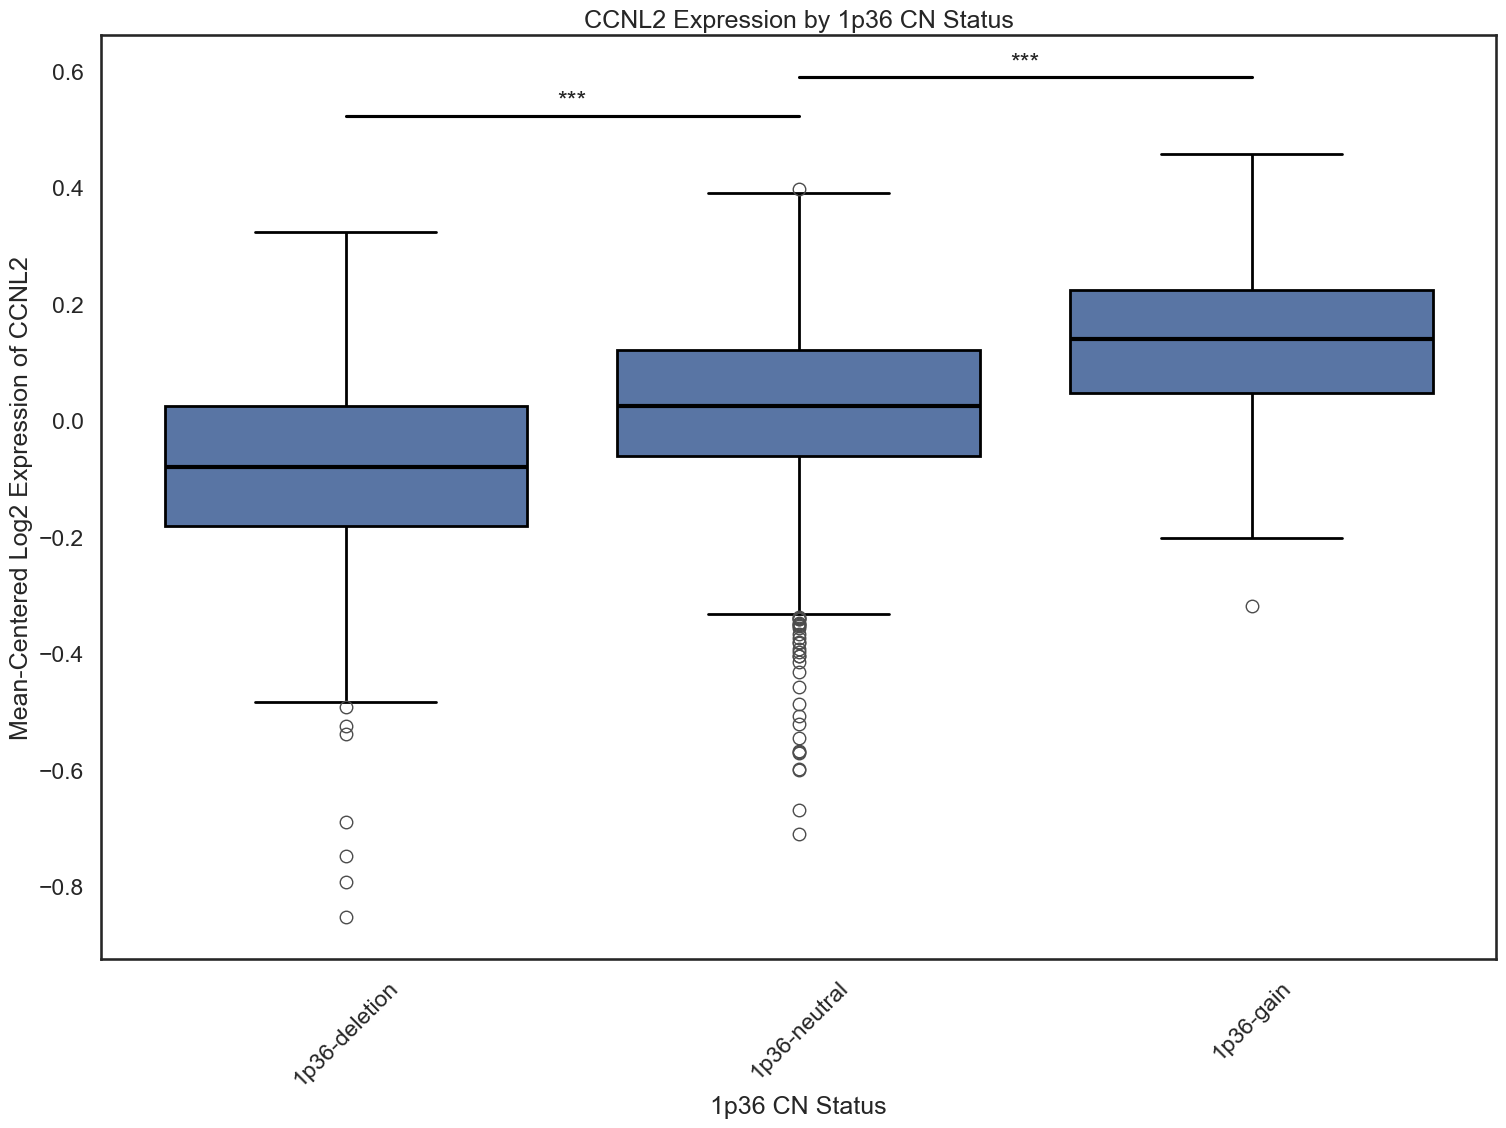

Box plots saved successfully in: /Users/luqiao/Library/CloudStorage/OneDrive-Stanford/CDK11-paper/Supplementary_Figs/


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import os

# Define save directory
save_dir = "Supplementary_Figs/"

# Load CNV data
cn_file = "Figure4/data/crispr/1p36_CN.csv"
cn_df = pd.read_csv(cn_file)  # Adjust delimiter if needed

# Load Expression data
expr_file = "Figure4/data/exp/1p36_Expression.csv"
expr_df = pd.read_csv(expr_file)  # Adjust delimiter if needed

# Ensure 'depmap_id' is common in both dataframes
merged_df = pd.merge(cn_df, expr_df, on="depmap_id", suffixes=("_cn", "_expr"))

# Calculate average CN for 1p36 region (CDK11A, CDK11B, CCNL2)
merged_df["1p36_avg_cn"] = merged_df[["CDK11A_cn", "CDK11B_cn", "CCNL2_cn"]].mean(axis=1)

# Categorize CN status
def categorize_cn_status(value):
    if value < 0.9:
        return "1p36-deletion"
    elif 0.9 <= value <= 1.2:
        return "1p36-neutral"
    else:
        return "1p36-gain"

merged_df["1p36_status"] = merged_df["1p36_avg_cn"].apply(categorize_cn_status)

# Define genes for separate box plots
genes = ["CDK11A_expr", "CDK11B_expr", "CCNL2_expr"]

# Mean-center the expression values
# Log-transform (with pseudocount) and mean-center expression values
for gene in genes:
    merged_df[gene] = np.log2(merged_df[gene] + 1)
    merged_df[gene] = merged_df[gene] - merged_df[gene].mean()


# Function to perform pairwise t-tests and return p-values
def get_pval(df, gene):
    group1 = df[df["1p36_status"] == "1p36-deletion"][gene]
    group2 = df[df["1p36_status"] == "1p36-neutral"][gene]
    group3 = df[df["1p36_status"] == "1p36-gain"][gene]

    pval_1_vs_2 = ttest_ind(group1, group2, nan_policy="omit").pvalue
    pval_2_vs_3 = ttest_ind(group2, group3, nan_policy="omit").pvalue

    return pval_1_vs_2, pval_2_vs_3

# Function to annotate significance
def get_sig_marker(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

# Create box plots with pairwise comparisons
for gene in genes:
    plt.figure(figsize=(18, 12))
    ax = sns.boxplot(x="1p36_status", y=gene, data=merged_df, 
                     order=["1p36-deletion", "1p36-neutral", "1p36-gain"],
                     boxprops={'edgecolor': 'black', 'linewidth': 2},
                     whiskerprops={'color': 'black', 'linewidth': 2},
                     capprops={'color': 'black', 'linewidth': 2},
                     medianprops={'color': 'black', 'linewidth': 3})
    
    # Get p-values
    pval_1_vs_2, pval_2_vs_3 = get_pval(merged_df, gene)
    print(gene)
    print(pval_1_vs_2, pval_2_vs_3)
    
    # Get significance markers
    sig_1_vs_2 = get_sig_marker(pval_1_vs_2)
    sig_2_vs_3 = get_sig_marker(pval_2_vs_3)
    
    # Annotate significance
    y_max = merged_df[gene].max()
    y_min = merged_df[gene].min()
    y_range = y_max - y_min
    y_offset = y_range * 0.05
    
    # Add horizontal lines for significance
    x_positions = [0, 1, 2]
    
    # 1 vs. 2
    plt.plot([x_positions[0], x_positions[1]], [y_max + y_offset, y_max + y_offset], color="black")
    plt.text((x_positions[0] + x_positions[1]) / 2, y_max + y_offset * 1.2, sig_1_vs_2, ha="center")
    
    # 2 vs. 3
    plt.plot([x_positions[1], x_positions[2]], [y_max + y_offset * 2, y_max + y_offset * 2], color="black")
    plt.text((x_positions[1] + x_positions[2]) / 2, y_max + y_offset * 2.2, sig_2_vs_3, ha="center")

    plt.xlabel("1p36 CN Status")
    plt.ylabel(f"Mean-Centered Log2 Expression of {gene.split('_')[0]}")
    plt.title(f"{gene.split('_')[0]} Expression by 1p36 CN Status")
    plt.xticks(rotation=45)

    # Save the figure
    # save_path = os.path.join(save_dir, f"{gene}_expression_boxplot.png")
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print("Box plots saved successfully in:", save_dir)


In [26]:
merged_df[["depmap_id", "CDK11A_expr", "CDK11B_expr", "CCNL2_expr", "1p36_status"]].to_csv("FigureS8A.csv")

# S8B

Error: 'Hugo_Symbol' column missing in chol_tcga
CDK11A
2.881347200620644e-67 0.0011981764948413738


/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_59569/939923723.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


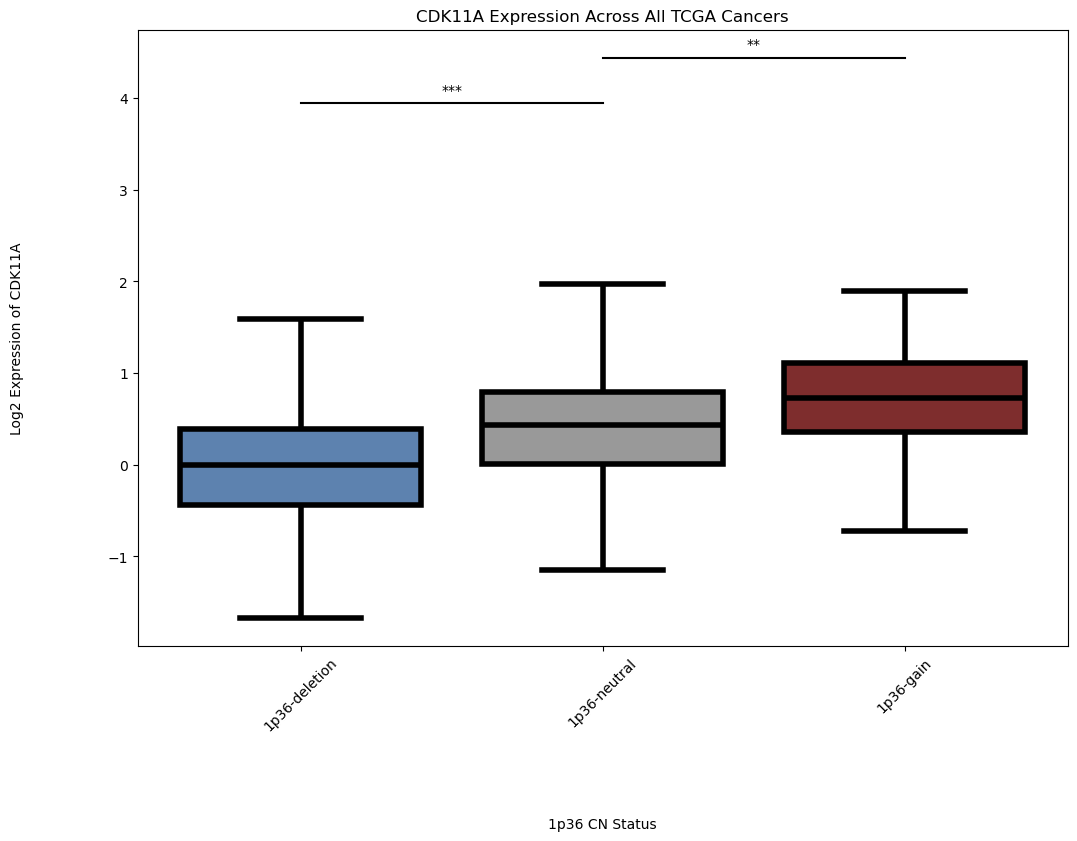

CDK11B
4.710656417235023e-108 9.962367952341545e-05


/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_59569/939923723.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


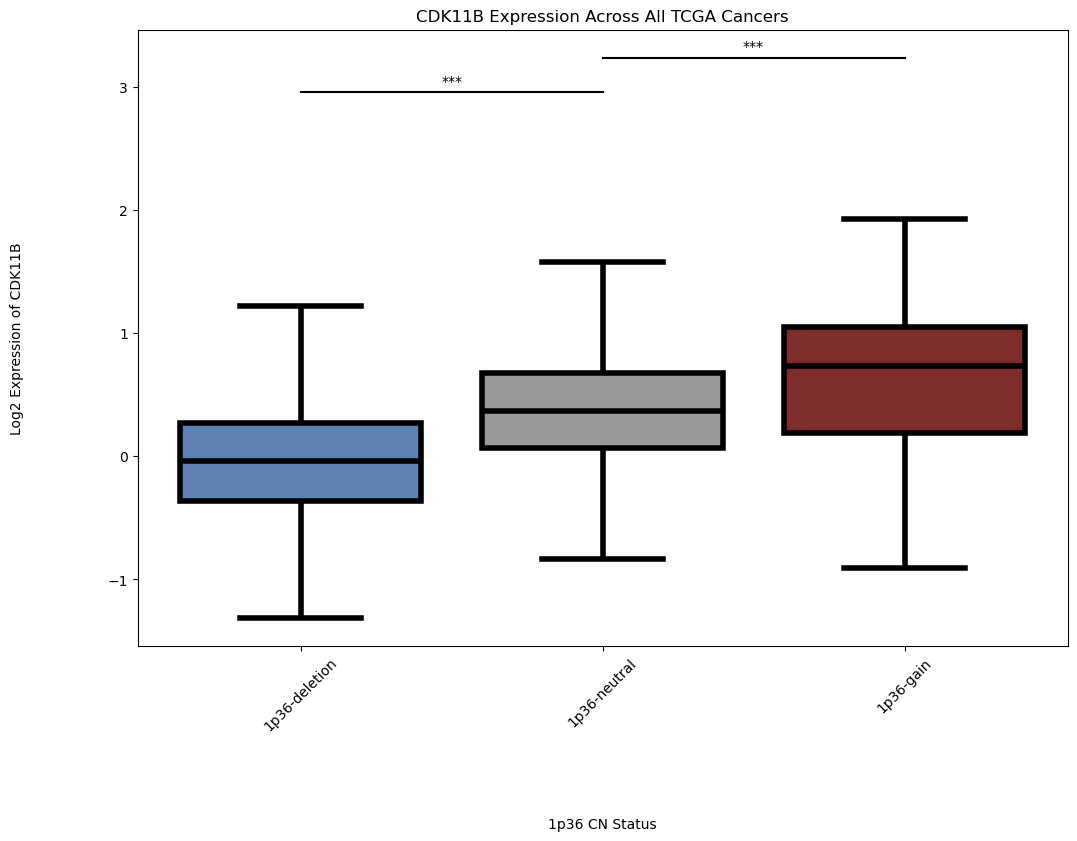

/var/folders/82/496ttv2x4lgdm_h08tr45wt40000gp/T/ipykernel_59569/939923723.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


CCNL2
2.5567143600940896e-48 0.2237666120042439


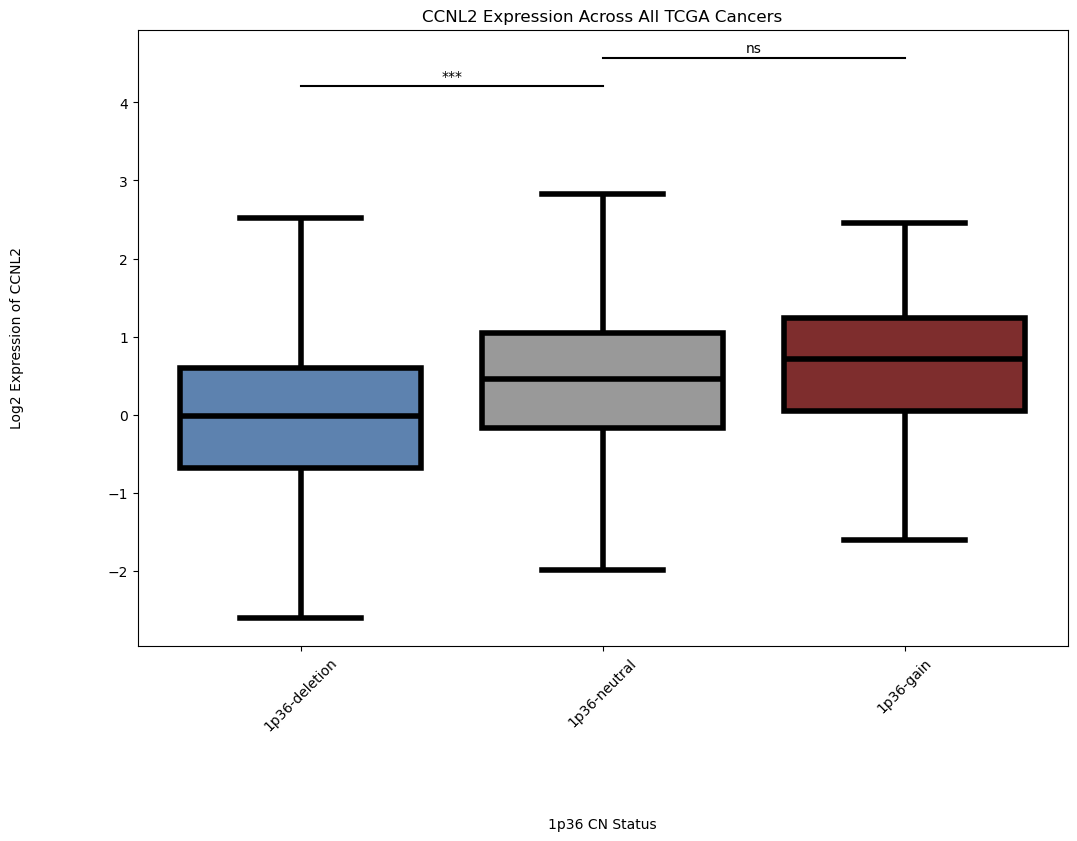

Box plots saved successfully for all TCGA cancers combined.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import os

# Define directories
cn_dir = "Supplementary_Figs/TCGA_CNA_Data"
expr_dir = "Supplementary_Figs/TCGA_Gene_Expression"
save_dir = ""

# Get list of cancer subfolders
subfolders = [f.name for f in os.scandir(cn_dir) if f.is_dir()]

# Define genes for analysis
genes = ["CDK11A", "CDK11B", "CCNL2"]

# Collect data across all cancers
all_merged_data = []

# Function to categorize copy number status
def categorize_cn_status(value):
    if value < 0.9:
        return "1p36-deletion"
    elif 0.9 <= value <= 1.2:
        return "1p36-neutral"
    else:
        return "1p36-gain"

# Process each cancer type
for subfolder in subfolders:
    cn_file = os.path.join(cn_dir, subfolder, "data_cna.txt")
    expr_file = os.path.join(expr_dir, subfolder, "data_mrna_seq_v2_rsem.txt")

    if not os.path.exists(cn_file) or not os.path.exists(expr_file):
        print(f"Skipping {subfolder}: Missing files")
        continue

    # Load CNV data
    cn_df = pd.read_csv(cn_file, sep="\t")
    cn_df.columns = cn_df.columns.str.strip()  # Fix column spacing issues

    # Load Expression data
    expr_df = pd.read_csv(expr_file, sep="\t")
    expr_df.columns = expr_df.columns.str.strip()  # Fix column spacing issues

    # Check if Hugo_Symbol is missing
    if "Hugo_Symbol" not in cn_df.columns or "Hugo_Symbol" not in expr_df.columns:
        print(f"Error: 'Hugo_Symbol' column missing in {subfolder}")
        continue

    # Filter for genes of interest
    cn_df = cn_df[cn_df["Hugo_Symbol"].isin(genes)]
    expr_df["Hugo_Symbol"] = expr_df["Hugo_Symbol"].replace({"CDC2L2": "CDK11A"})
    expr_df = expr_df.drop(columns=["Entrez_Gene_Id"])
    
    expr_df = expr_df[expr_df["Hugo_Symbol"].isin(genes)]

    # Skip if no data found
    if cn_df.empty or expr_df.empty:
        continue

    # Reshape (melt) both CNV and Expression data to long format
    cn_long = cn_df.melt(id_vars=["Hugo_Symbol"], var_name="Sample", value_name="CN_Value")
    expr_long = expr_df.melt(id_vars=["Hugo_Symbol"], var_name="Sample", value_name="Expression")

    # Merge CNV and expression data
    merged_df = pd.merge(cn_long, expr_long, on=["Hugo_Symbol", "Sample"], how="inner")

    # Add cancer type column for reference
    merged_df["Cancer_Type"] = subfolder

    # Append to the full dataset
    all_merged_data.append(merged_df)

# Combine all data
final_df = pd.concat(all_merged_data, ignore_index=True)

# Compute average CN status for 1p36 region per sample
avg_cn_df = final_df.groupby("Sample")["CN_Value"].mean().reset_index()
avg_cn_df.rename(columns={"CN_Value": "1p36_avg_cn"}, inplace=True)

# Categorize CN status
avg_cn_df["1p36_status"] = avg_cn_df["1p36_avg_cn"].apply(categorize_cn_status)

# Merge categorized CN status back
final_df = pd.merge(final_df, avg_cn_df, on="Sample")

# Apply log2 transformation to expression values
final_df["log2_Expression"] = np.log2(final_df["Expression"] + 1)  # Add 1 to avoid log(0)
final_df["log2_Expression_centered"] = final_df.groupby("Hugo_Symbol")["log2_Expression"].transform(lambda x: x - x.mean())


# Function to perform t-tests
def get_pval(df, gene):
    group1 = df[df["1p36_status"] == "1p36-deletion"]["log2_Expression"]
    group2 = df[df["1p36_status"] == "1p36-neutral"]["log2_Expression"]
    group3 = df[df["1p36_status"] == "1p36-gain"]["log2_Expression"]

    pval_1_vs_2 = ttest_ind(group1, group2, nan_policy="omit").pvalue
    pval_2_vs_3 = ttest_ind(group2, group3, nan_policy="omit").pvalue

    return pval_1_vs_2, pval_2_vs_3

# Function to get significance markers
def get_sig_marker(pval):
    if pval < 0.001:
        return "***"
    elif pval < 0.01:
        return "**"
    elif pval < 0.05:
        return "*"
    else:
        return "ns"

# Create combined box plots for all genes
for gene in genes:
    gene_df = final_df[final_df["Hugo_Symbol"] == gene]

    palette = {
    "1p36-deletion": "#4F81BD",
    "1p36-neutral":  "#999999",
    "1p36-gain":     "#8B2020",
    }

    plt.figure(figsize=(12, 8))
    ax = sns.boxplot(
        x="1p36_status",
        y="log2_Expression_centered",
        data=gene_df,
        order=["1p36-deletion", "1p36-neutral", "1p36-gain"],
        palette=palette,
        showfliers=False,
        boxprops={'edgecolor': 'black', 'linewidth': 4},
        whiskerprops={'color': 'black', 'linewidth': 4},
        capprops={'color': 'black', 'linewidth': 4},
        medianprops={'color': 'black', 'linewidth': 4},
        flierprops={'marker': ''},
    )

    # Get p-values
    pval_1_vs_2, pval_2_vs_3 = get_pval(gene_df, "log2_Expression")
    print(gene)
    print(pval_1_vs_2, pval_2_vs_3)

    # Get significance markers
    sig_1_vs_2 = get_sig_marker(pval_1_vs_2)
    sig_2_vs_3 = get_sig_marker(pval_2_vs_3)

    # Annotate significance
    y_max = gene_df["log2_Expression_centered"].max()
    y_min = gene_df["log2_Expression_centered"].min()
    y_range = y_max - y_min
    y_offset = y_range * 0.05

    x_positions = [0, 1, 2]

    # 1 vs. 2
    plt.plot([x_positions[0], x_positions[1]], [y_max + y_offset, y_max + y_offset], color="black")
    plt.text((x_positions[0] + x_positions[1]) / 2, y_max + y_offset * 1.2, sig_1_vs_2, ha="center")

    # 2 vs. 3
    plt.plot([x_positions[1], x_positions[2]], [y_max + y_offset * 2, y_max + y_offset * 2], color="black")
    plt.text((x_positions[1] + x_positions[2]) / 2, y_max + y_offset * 2.2, sig_2_vs_3, ha="center")

    plt.xlabel("1p36 CN Status", labelpad=60)
    plt.ylabel(f"Log2 Expression of {gene}", labelpad=60)
    plt.title(f"{gene} Expression Across All TCGA Cancers")
    plt.xticks(rotation=45)

    # Save the figure
    # save_path = os.path.join(save_dir, f"All_TCGA_{gene}_expression_boxplot.svg")
    # plt.savefig(save_path, dpi=300, bbox_inches="tight")
    # plt.savefig(save_path, bbox_inches='tight', dpi=300, pad_inches=0.5)
    plt.show()
    plt.close()

print("Box plots saved successfully for all TCGA cancers combined.")

In [3]:
print(pval_1_vs_2, pval_2_vs_3)

2.5567143600940896e-48 6.208074898339951e-34


# S9D

In [ ]:
#CRISPR Screen
#Letality genes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
file_path = "GO_Biological_Process_2025_table_Lethal.txt"
df = pd.read_csv(file_path, sep="\t")
# Filter to only keep deleted GO terms
deleted_go_terms = [
    "IMP Metabolic Process (GO:0046040)",
    "Purine Ribonucleoside Monophosphate Metabolic Process (GO:0009167)",
    "RNA Splicing, via Transesterification Reactions With Bulged Adenosine as Nucleophile (GO:0000377)",
    "Purine Ribonucleotide Metabolic Process (GO:0009150)",
    "mRNA Splicing, via Spliceosome (GO:0000398)",
    "mRNA Processing (GO:0006397)",
    "GMP Biosynthetic Process (GO:0006177)"
]

# Keep only rows matching these GO terms
df = df[df["Term"].isin(deleted_go_terms)]

# Convert Adjusted P-value to numeric and compute -log10(P-value)
df["Adjusted P-value"] = pd.to_numeric(df["Adjusted P-value"], errors="coerce")
df.dropna(subset=["Adjusted P-value"], inplace=True)
df["-log10(Adjusted P-value)"] = -np.log10(df["Adjusted P-value"])

# Sort terms by significance
df.sort_values("Adjusted P-value", inplace=True)

# Create plot
fig, ax = plt.subplots(figsize=(24, 8), facecolor="white") 
ax.set_facecolor("white")

# Plot
bars = ax.barh(df["Term"], df["-log10(Adjusted P-value)"], color="royalblue")

# Labels and titles
ax.set_xlabel("-log10(Adjusted P-value)", fontsize=16, fontweight="bold", color="black")
ax.set_ylabel("GO Term", fontsize=16, fontweight="bold", color="black")
ax.set_title("Enriched GO Terms for Synthetic Lethal Interactions", fontsize=18, fontweight="bold", color="black")
plt.xticks([0,0.5,1,1.5])
# Format axes
ax.tick_params(axis="both", which="major", labelsize=14)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.7)

# Format borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

# Save
output_path = "GO_Biological_Process_2025_table_Lethal.png"
plt.tight_layout()
# plt.savefig(output_path, dpi=600, bbox_inches='tight', facecolor="white")
plt.show()


In [ ]:
#CRISPR Screen
#Rescue Genes

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Load the data
file_path = f"GO_Biological_Process_2025_table_Rescue.txt"
df = pd.read_csv(file_path, sep="\t")

# Convert Adjusted P-value to numeric and compute -log10(P-value)
df["Adjusted P-value"] = pd.to_numeric(df["Adjusted P-value"], errors="coerce")
df.dropna(subset=["Adjusted P-value"], inplace=True)
df["-log10(Adjusted P-value)"] = -np.log10(df["Adjusted P-value"])

# Sort by adjusted P-value (smallest first)
filtered_df = df.nsmallest(10, "Adjusted P-value")

# Create plot with explicit background settings
fig, ax = plt.subplots(figsize=(14, 8), facecolor="white") 
ax.set_facecolor("white")

# Plot
bars = ax.barh(filtered_df["Term"], filtered_df["-log10(Adjusted P-value)"], color="royalblue")

# Set labels and title with improved font size
ax.set_xlabel("-log10(Adjusted P-value)", fontsize=16, fontweight="bold", color="black")
ax.set_ylabel("GO Term", fontsize=16, fontweight="bold", color="black")
ax.set_title(f" Enriched GO-Terms for Synthetic Rescue Interactions", fontsize=18, fontweight="bold", color="black")

# Increase tick font sizes
ax.tick_params(axis="both", which="major", labelsize=14)

# Invert y-axis for better readability
ax.invert_yaxis()

# Add gridlines for clarity
ax.grid(axis="x", linestyle="--", alpha=0.7)

# Set axis spine colors
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1)
    spine.set_color("black")

# Ensure tight layout and save
output_path = f"GO_Biological_Process_2025_table_Rescue.png"
plt.tight_layout()
plt.savefig(output_path, dpi=600, bbox_÷inches='tight', facecolor="white")
plt.show()
